# Librairies 📚

In [1]:
# =========================
# Standard library
# =========================
import os
import sys
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

# =========================
# Local imports (src/)
# =========================
sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers as of

# Import de la table 🪑

In [2]:
info_backup = pd.read_csv("/home/maxime/projects/technova-attrition/data/raw/extrait_sirh.csv.csv")
info_backup.head(2)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7


In [3]:
info = info_backup.copy()
info.shape

(1470, 12)

In [4]:
eval_backup = pd.read_csv("/home/maxime/projects/technova-attrition/data/raw/extrait_eval.csv")
eval_backup.head(2)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %


In [5]:
df_eval = eval_backup.copy()
df_eval.shape

(1470, 10)

In [6]:
poll_backup = pd.read_csv("/home/maxime/projects/technova-attrition/data/raw/extrait_sondage.csv")
poll_backup.head(2)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7


In [7]:
poll = poll_backup.copy()
poll.shape

(1470, 12)

# A.1 Table info (SIRH) ℹ️

## Premier nettoyage des données 🧹

In [8]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


In [9]:
info.drop("id_employee",axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
nombre_heures_travailless,1470.0,80.000000,0.000000,80.0,80.0,80.0,80.0,80.0
annee_experience_totale,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.0,3.0,7.0,18.0


### Valeurs nulles 👌(❎ pas de valeur nulle)

In [10]:
info.isna().mean().sort_values(ascending=False)

id_employee                       0.0
age                               0.0
genre                             0.0
revenu_mensuel                    0.0
statut_marital                    0.0
departement                       0.0
poste                             0.0
nombre_experiences_precedentes    0.0
nombre_heures_travailless         0.0
annee_experience_totale           0.0
annees_dans_l_entreprise          0.0
annees_dans_le_poste_actuel       0.0
dtype: float64

### Suppression des doublons 👥 (❎ Pas de doublons)

In [11]:
info.duplicated().sum()

0

## Analyses univariées 

In [12]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id_employee                     1470 non-null   int64 
 1   age                             1470 non-null   int64 
 2   genre                           1470 non-null   object
 3   revenu_mensuel                  1470 non-null   int64 
 4   statut_marital                  1470 non-null   object
 5   departement                     1470 non-null   object
 6   poste                           1470 non-null   object
 7   nombre_experiences_precedentes  1470 non-null   int64 
 8   nombre_heures_travailless       1470 non-null   int64 
 9   annee_experience_totale         1470 non-null   int64 
 10  annees_dans_l_entreprise        1470 non-null   int64 
 11  annees_dans_le_poste_actuel     1470 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.9+ KB


### Valeurs ordinales

In [13]:
info.statut_marital.value_counts()

statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

In [14]:
info.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel'],
      dtype='object')

In [15]:
info[["statut_marital","genre","departement","poste"]].columns

Index(['statut_marital', 'genre', 'departement', 'poste'], dtype='object')

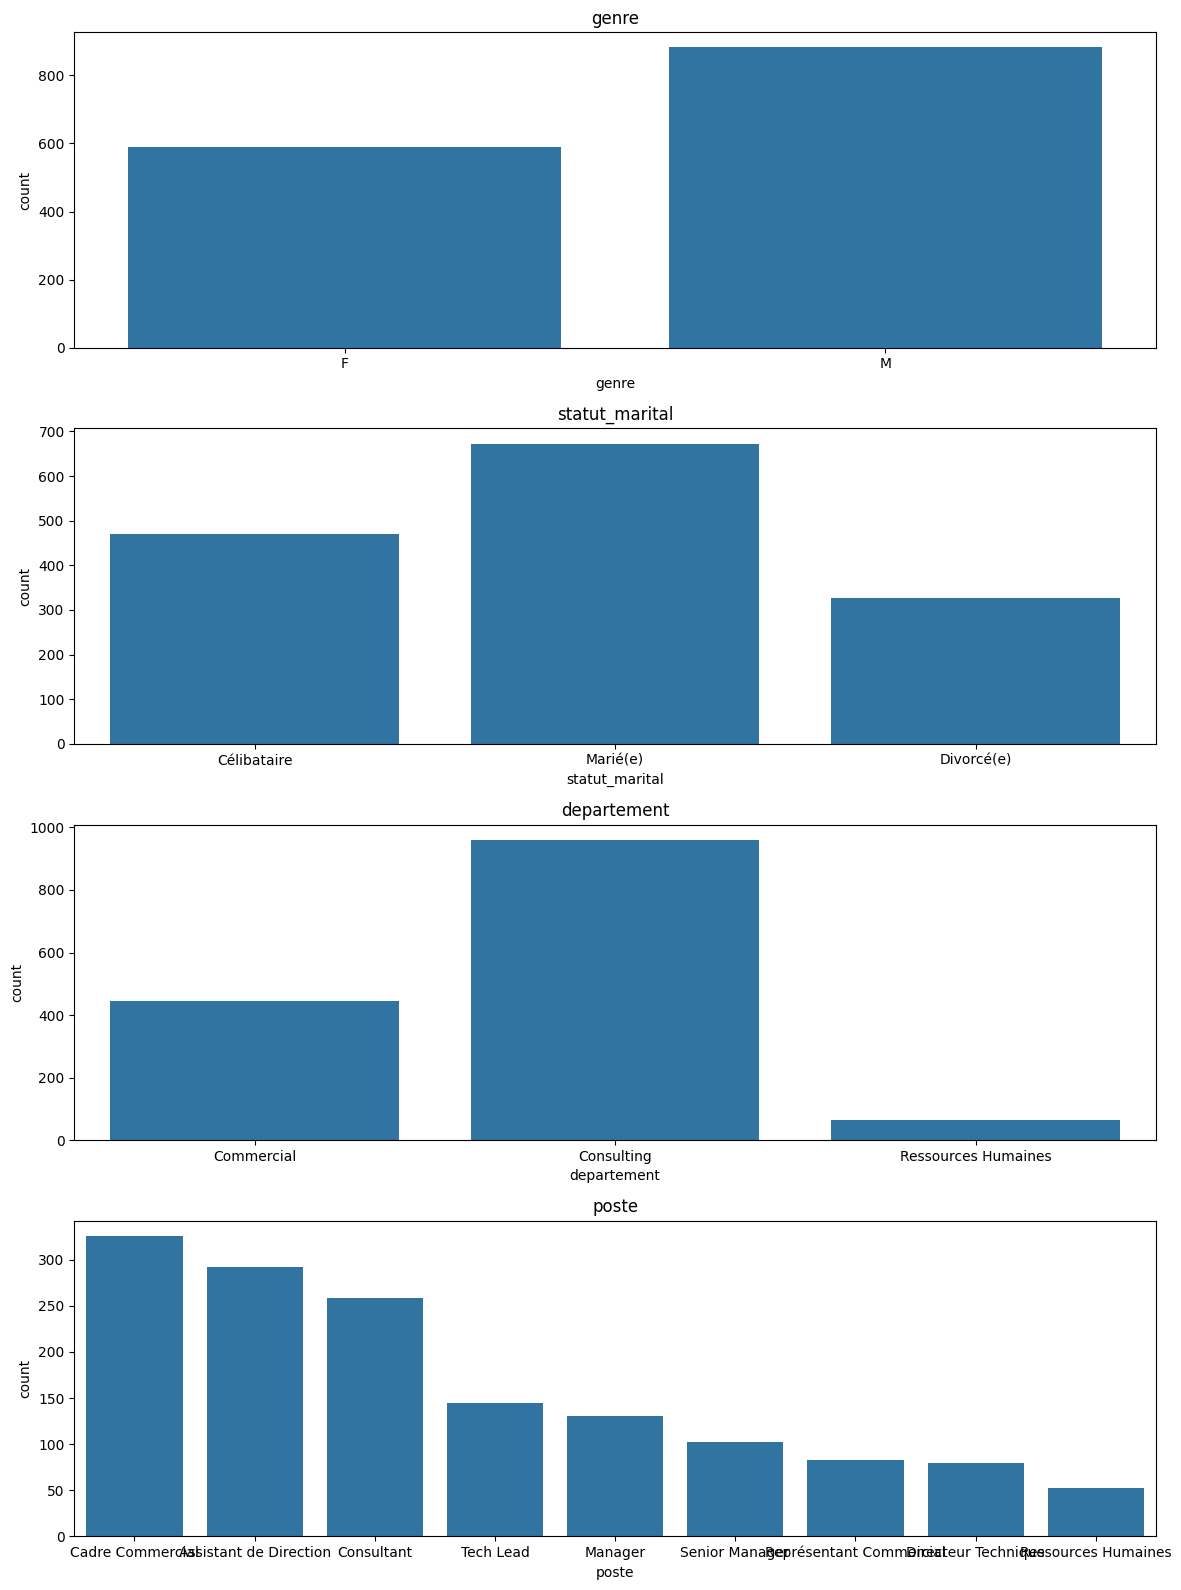

In [16]:
cols = info.select_dtypes(exclude='number').columns

n_cols = 1  # 👉 2 graphes par ligne
n_plots = len(cols)
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=info[col], ax=axes[i])
    axes[i].set_title(col)

# supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Valeurs numériques

#### Outliers 😶

In [17]:
data = info.drop("id_employee",axis=1).select_dtypes(include="number")

In [18]:
outliers, ratio = of.detect_outliers_iqr(data)
ratio.sort_values(ascending=False)

revenu_mensuel                    7.755102
annees_dans_l_entreprise          7.074830
annee_experience_totale           4.285714
nombre_experiences_precedentes    3.537415
annees_dans_le_poste_actuel       1.428571
age                               0.000000
nombre_heures_travailless         0.000000
dtype: float64

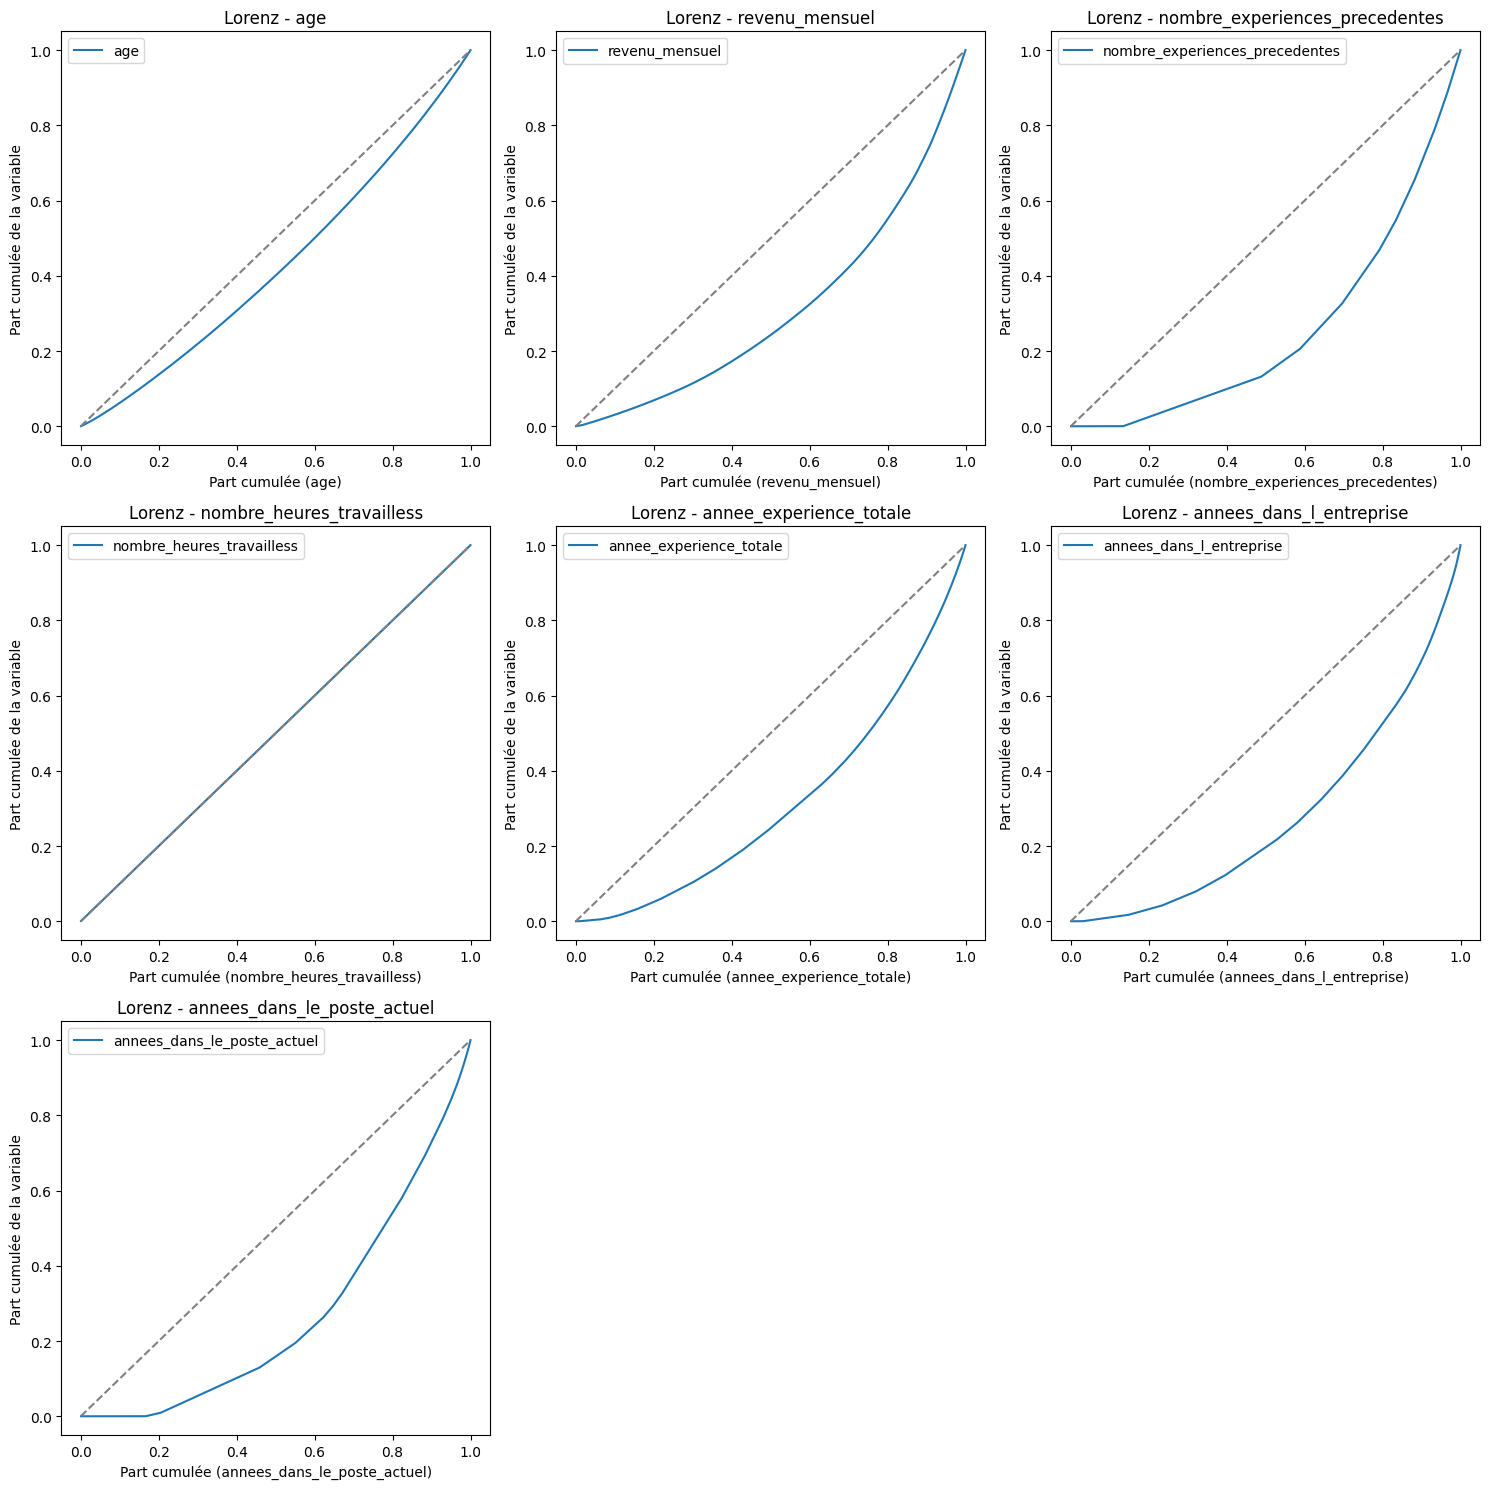

In [19]:
n_cols = 3
n_plots = len(data.columns)

n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, (col, serie) in enumerate(data.items()):
    of.plot_lorenz(
        serie,
        ax=axes[i],
        label=col,
        title=f"Lorenz - {col}"
    )

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

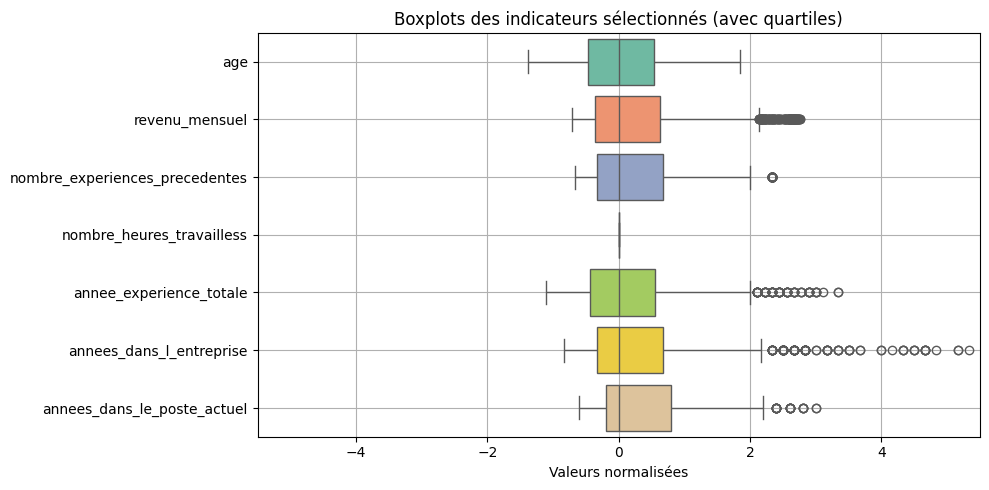

In [20]:
data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data),
    columns=data.columns
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("")
plt.xlabel("Valeurs normalisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()

3 types de variables :

    Type 1 : Homogènes ==> age, nombre_heures_travaillées : 0% d'outliers

    Type 2 : Moyennement inégal ==> annee_experience_totale, annees_dans_l_entreprise : 3-7% d'outliers

    Type 3 : Très concentré (IMPORTANT) ==> revenu_mensuel, nombre_experiences_precedentes, annees_dans_le_poste_actuel : 7.7% outliers

    ==> 3 variable à log pour le model 

#### Skwed

In [21]:
#data = info[["revenu_mensuel", "nombre_experiences_precedentes", "annees_dans_le_poste_actuel"]]
data.skew().sort_values(ascending=False)

annees_dans_l_entreprise          1.764529
revenu_mensuel                    1.369817
annee_experience_totale           1.117172
nombre_experiences_precedentes    1.026471
annees_dans_le_poste_actuel       0.917363
age                               0.413286
nombre_heures_travailless         0.000000
dtype: float64

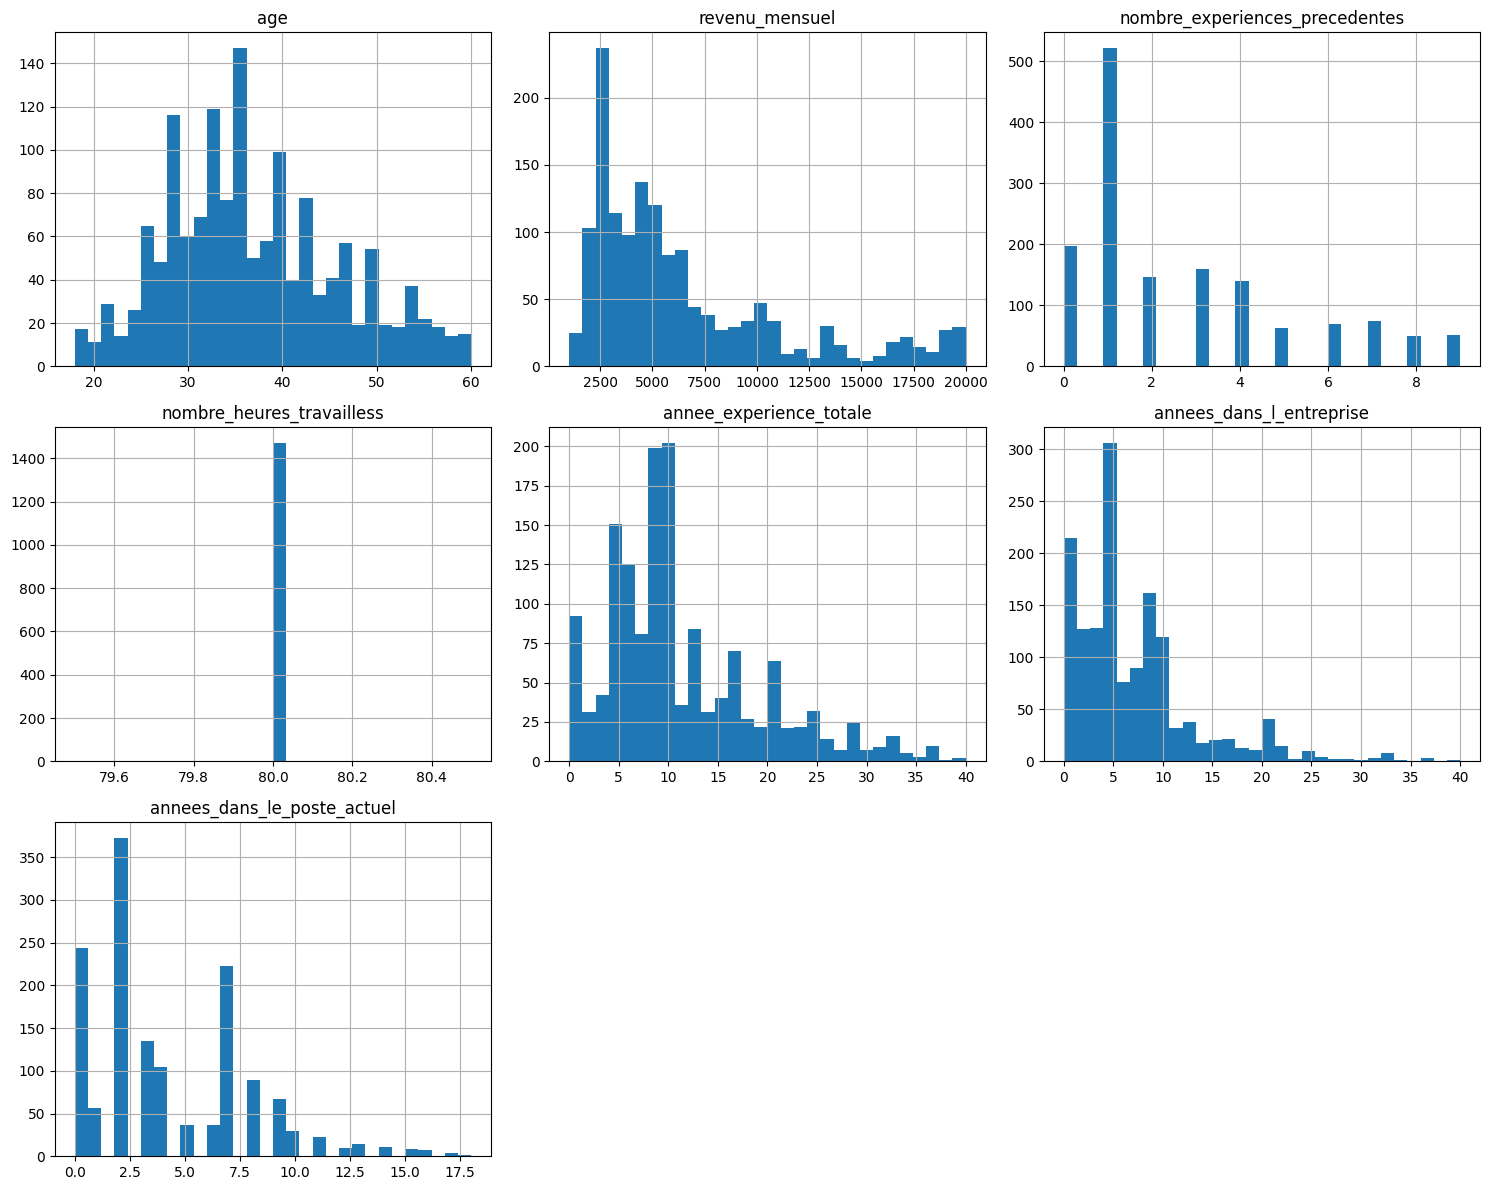

In [22]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

## 🧠 Analyse univariée - info — Synthèse & Actions

### 1. ⚠️ Analyse des outliers (IQR)

* Jusqu’à ~8% d’outliers sur certaines variables (notamment `revenu_mensuel`)
* Ces outliers sont **structurels** (non aberrants métier)

➡️ **Aucune suppression d’outliers recommandée**

---

### 2. 📊 Swed

#### 🟠 Variables modérément asymétriques

* `annee_experience_totale`
* `annees_dans_l_entreprise`

➡️ Distribution réaliste avec une dispersion modérée.

---

#### 🔴 Variables fortement asymétriques (skew à droite)

* `revenu_mensuel`
* `annees_dans_le_poste_actuel`
* `nombre_experiences_precedentes`

➡️ Présence de valeurs extrêmes et forte concentration (confirmée par la courbe de Lorenz).

---

### ✅ Variables potentiellement à transformer (selon modèle)

```python
[
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel"
]
```
### 📌 Conclusion

L’analyse univariée met en évidence des distributions hétérogènes avec :

* des variables homogènes (âge),
* des variables modérément dispersées (expérience),
* et des variables fortement asymétriques (revenu).

Ces résultats orientent les choix de preprocessing et confirment l’intérêt d’utiliser des modèles robustes aux distributions non gaussiennes.

---


## Analyses bivariées 🪢

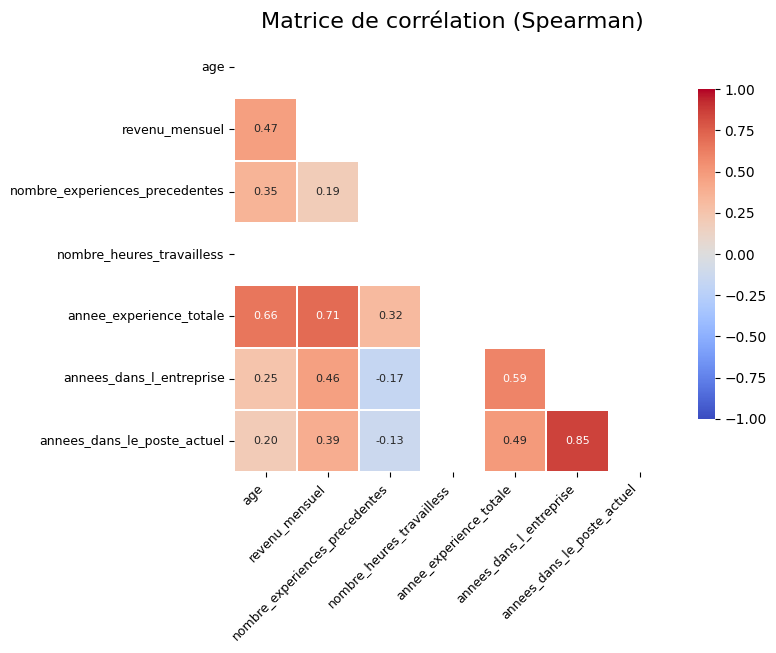

In [23]:
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
corr = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.854000
1,revenu_mensuel,annee_experience_totale,0.710024


In [25]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = info[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

,feature,VIF
0,annees_dans_le_poste_actuel,5.189112
1,revenu_mensuel,6.917388
2,annees_dans_l_entreprise,7.084440
3,annee_experience_totale,8.915268


# A.2 Table df_eval

## Premier nettoyage des données 🧹

In [26]:
df_eval.head(5)

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [27]:
df_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   object
dtypes: int64(7), object(3)
memory usage:

### Valeurs nulles 👌(❎ pas de valeur nulle)

In [28]:
df_eval.isna().mean().sort_values(ascending=False)

satisfaction_employee_environnement          0.0
note_evaluation_precedente                   0.0
niveau_hierarchique_poste                    0.0
satisfaction_employee_nature_travail         0.0
satisfaction_employee_equipe                 0.0
satisfaction_employee_equilibre_pro_perso    0.0
eval_number                                  0.0
note_evaluation_actuelle                     0.0
heure_supplementaires                        0.0
augementation_salaire_precedente             0.0
dtype: float64

### Suppression des doublons 👥 (❎ Pas de doublons)

In [29]:
df_eval.duplicated().sum()

0

### Convertion des données ☪️

In [30]:
df_eval.eval_number.nunique(), df_eval.shape # Clé unique de la table

(1470, (1470, 10))

In [31]:
df_eval.heure_supplementaires.value_counts(normalize=True).round(2)

heure_supplementaires
Non    0.72
Oui    0.28
Name: proportion, dtype: float64

In [32]:
df_eval["heure_supplementaires"] = (
    df_eval["heure_supplementaires"]
    .map({"Oui": 1, "Non": 0})
)

In [33]:
df_eval.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente'],
      dtype='object')

In [34]:
df_eval["augementation_salaire_precedente"] = (
    df_eval["augementation_salaire_precedente"]
    .str.replace("%", "", regex=False)   # enlève %
    .str.replace(",", ".", regex=False)  # remplace virgule
    .str.strip()                         # enlève espaces
    .astype(float) / 100                 # convertit en proportion
)

## Analyses univariés

### A. Variables ordinales (satisfaction + niveau)

In [35]:
for col in df_eval.filter(like="satisfaction"):
    print(df_eval[col].value_counts(normalize=True))

satisfaction_employee_environnement
3    0.308163
4    0.303401
2    0.195238
1    0.193197
Name: proportion, dtype: float64
satisfaction_employee_nature_travail
4    0.312245
3    0.300680
1    0.196599
2    0.190476
Name: proportion, dtype: float64
satisfaction_employee_equipe
3    0.312245
4    0.293878
2    0.206122
1    0.187755
Name: proportion, dtype: float64
satisfaction_employee_equilibre_pro_perso
3    0.607483
2    0.234014
4    0.104082
1    0.054422
Name: proportion, dtype: float64


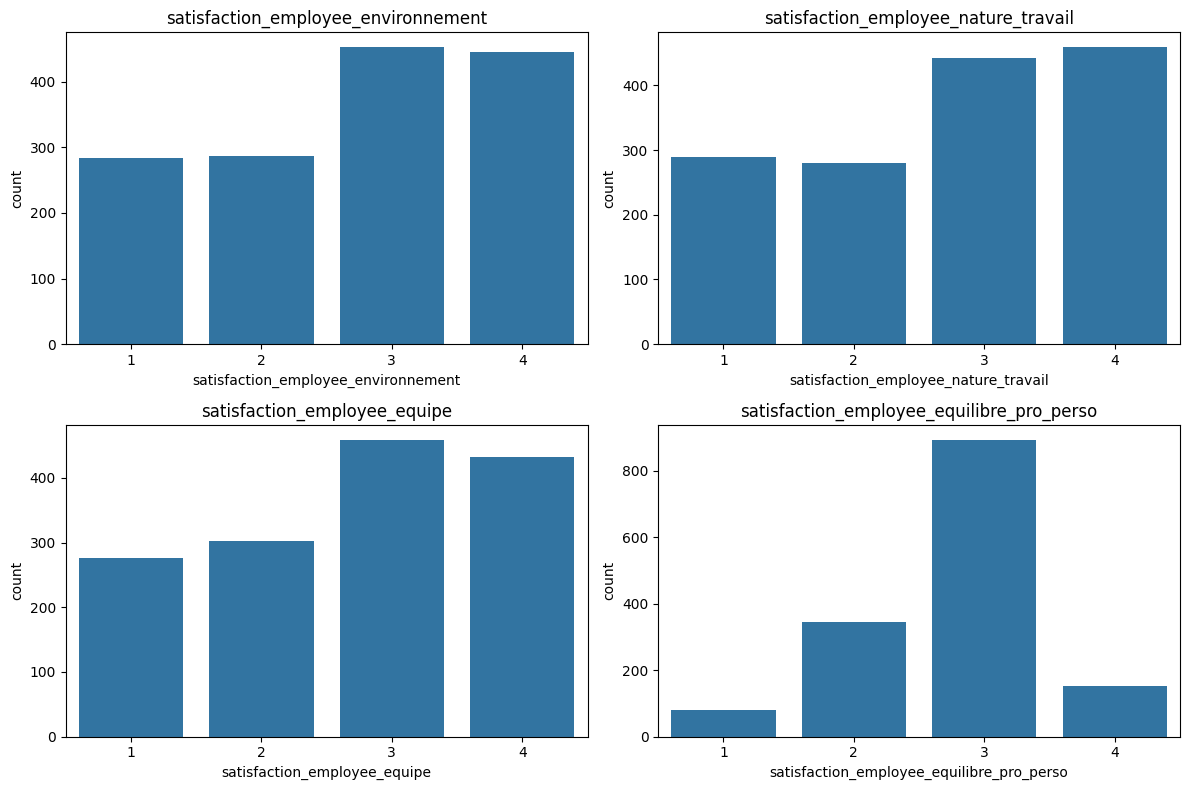

In [36]:
cols = df_eval.filter(like="satisfaction").columns

n_cols = 2  # 👉 2 graphes par ligne
n_plots = len(cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df_eval[col], ax=axes[i])
    axes[i].set_title(col)

# supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

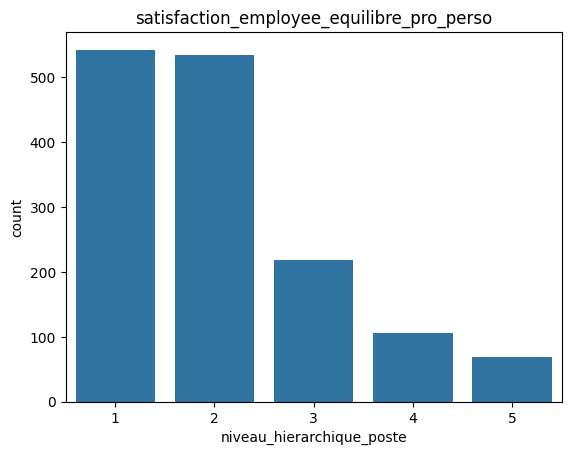

In [37]:
sns.countplot(x=df_eval["niveau_hierarchique_poste"])
plt.title(col)
plt.show()

In [38]:
satisfaction_cols = df_eval.filter(like="satisfaction").columns

df_eval["satisfaction_global"] = df_eval[satisfaction_cols].mean(axis=1)

<Axes: xlabel='satisfaction_global', ylabel='Count'>

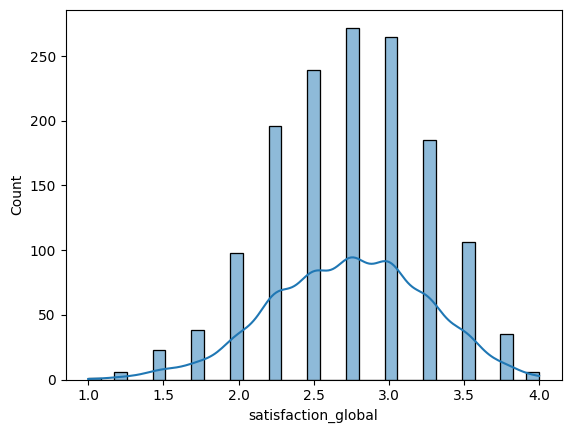

In [39]:
sns.histplot(df_eval["satisfaction_global"], kde=True)

### B. Variables quantitatives

In [40]:
df_eval["augementation_salaire_precedente"].describe()

count    1470.000000
mean        0.152095
std         0.036599
min         0.110000
25%         0.120000
50%         0.140000
75%         0.180000
max         0.250000
Name: augementation_salaire_precedente, dtype: float64

<Axes: xlabel='augementation_salaire_precedente', ylabel='Count'>

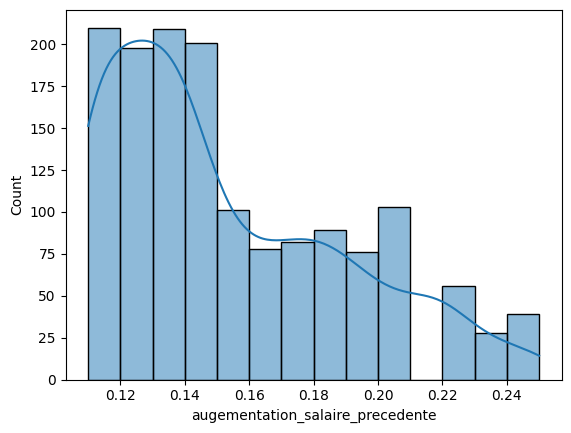

In [41]:
sns.histplot(df_eval["augementation_salaire_precedente"], kde=True)

In [42]:
df_eval.note_evaluation_actuelle.value_counts()

note_evaluation_actuelle
3    1244
4     226
Name: count, dtype: int64

#### Outliers 😶

In [43]:
data = df_eval.drop(["eval_number","heure_supplementaires"],axis=1).select_dtypes(include="number")

In [44]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.00,2.00,3.00,4.00,4.00
note_evaluation_precedente,1470.0,2.729932,0.711561,1.00,2.00,3.00,3.00,4.00
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.00,1.00,2.00,3.00,5.00
satisfaction_employee_nature_travail,1470.0,2.728571,1.102846,1.00,2.00,3.00,4.00,4.00
satisfaction_employee_equipe,1470.0,2.712245,1.081209,1.00,2.00,3.00,4.00,4.00
satisfaction_employee_equilibre_pro_perso,1470.0,2.761224,0.706476,1.00,2.00,3.00,3.00,4.00
note_evaluation_actuelle,1470.0,3.153741,0.360824,3.00,3.00,3.00,3.00,4.00
augementation_salaire_precedente,1470.0,0.152095,0.036599,0.11,0.12,0.14,0.18,0.25
satisfaction_global,1470.0,2.730952,0.505815,1.00,2.50,2.75,3.00,4.00


In [45]:
outliers, ratio = of.detect_outliers_iqr(data)
ratio.sort_values(ascending=False)

note_evaluation_actuelle                     15.37415
satisfaction_global                           2.44898
satisfaction_employee_environnement           0.00000
note_evaluation_precedente                    0.00000
niveau_hierarchique_poste                     0.00000
satisfaction_employee_nature_travail          0.00000
satisfaction_employee_equipe                  0.00000
satisfaction_employee_equilibre_pro_perso     0.00000
augementation_salaire_precedente              0.00000
dtype: float64

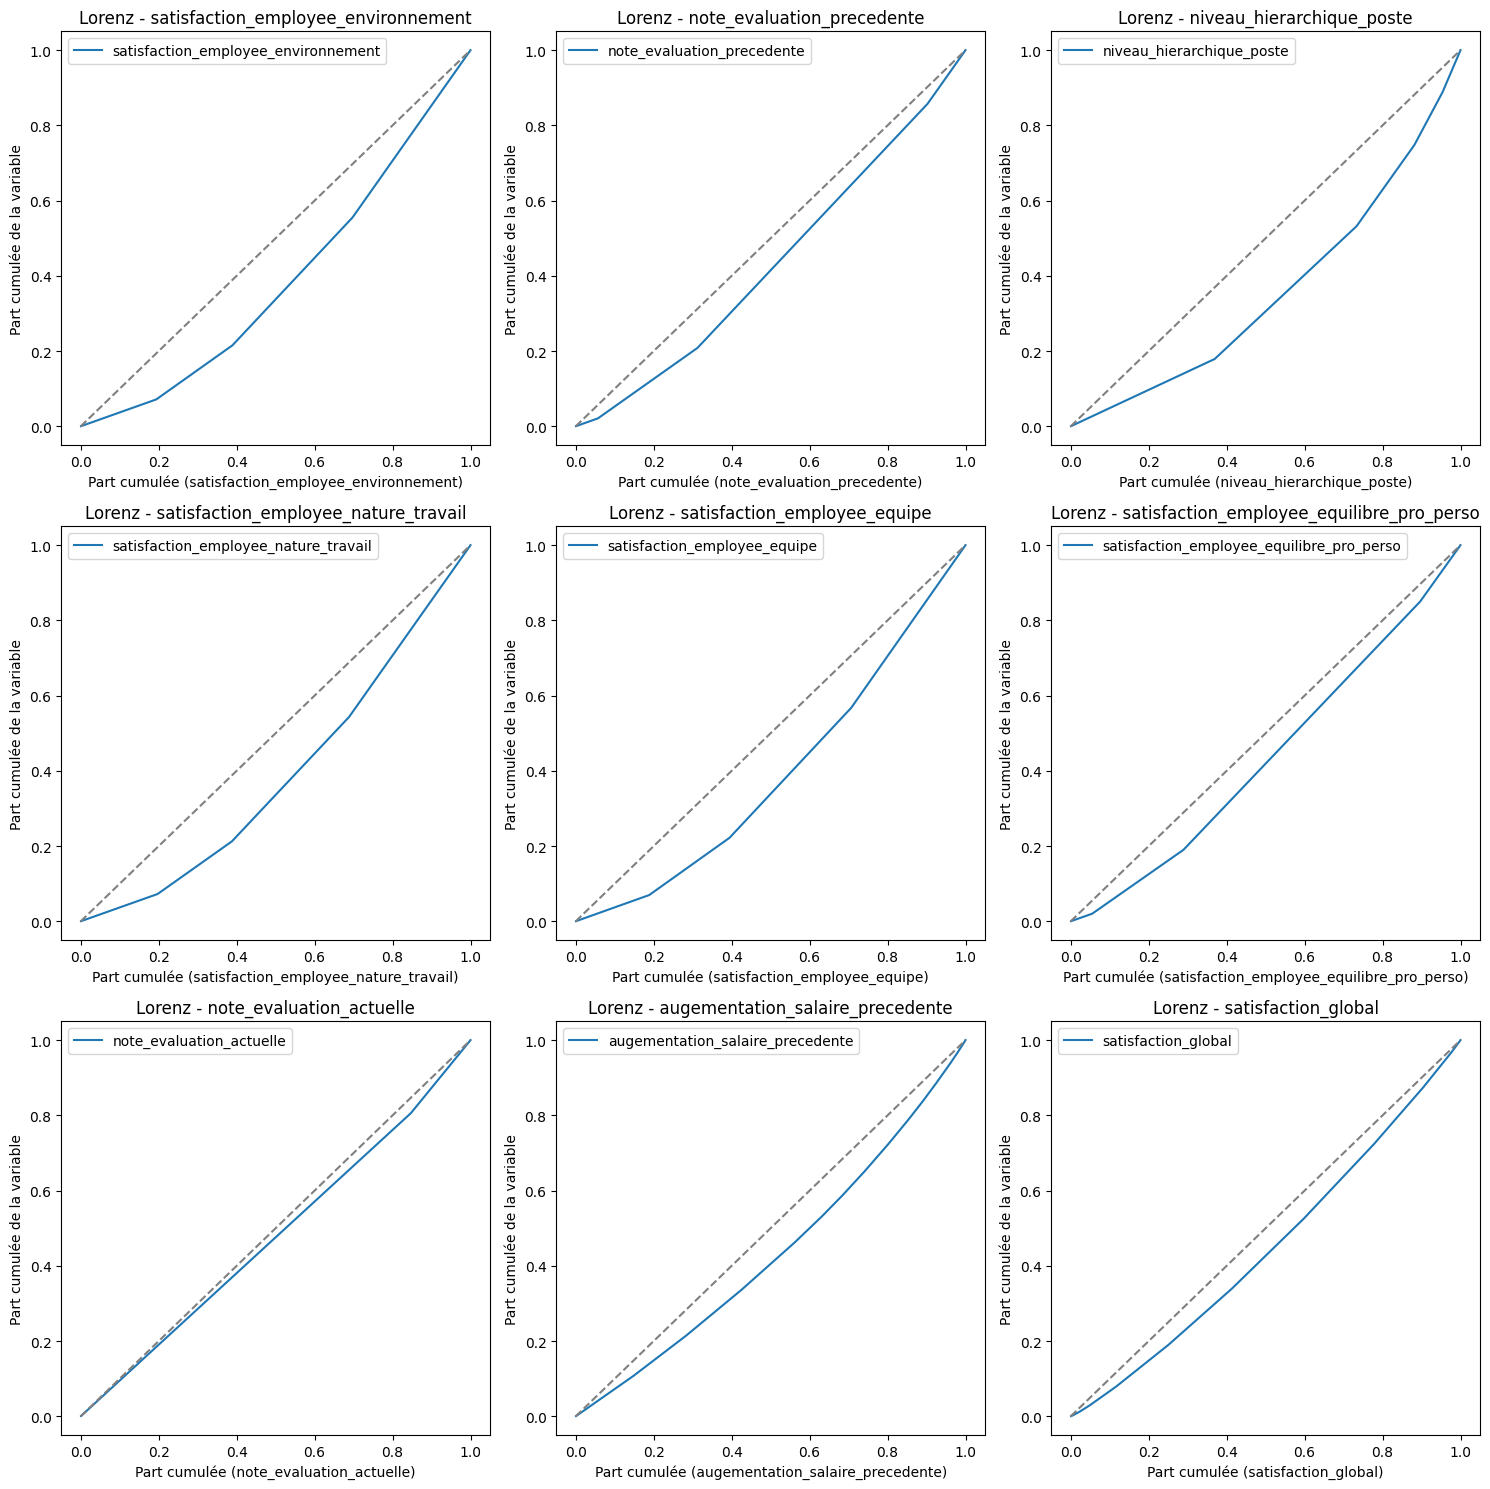

In [46]:
n_cols = 3
n_plots = len(data.columns)

n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, (col, serie) in enumerate(data.items()):
    of.plot_lorenz(
        serie,
        ax=axes[i],
        label=col,
        title=f"Lorenz - {col}"
    )

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

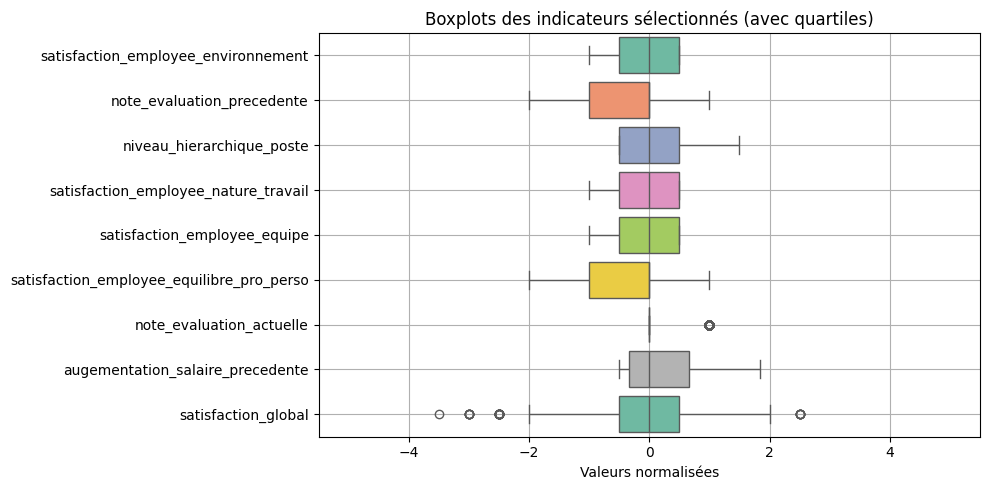

In [47]:
data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data),
    columns=data.columns
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("")
plt.xlabel("Valeurs normalisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Skwed

In [48]:
data.skew()

satisfaction_employee_environnement         -0.321654
note_evaluation_precedente                  -0.498419
niveau_hierarchique_poste                    1.025401
satisfaction_employee_nature_travail        -0.329672
satisfaction_employee_equipe                -0.302828
satisfaction_employee_equilibre_pro_perso   -0.552480
note_evaluation_actuelle                     1.921883
augementation_salaire_precedente             0.821128
satisfaction_global                         -0.199736
dtype: float64

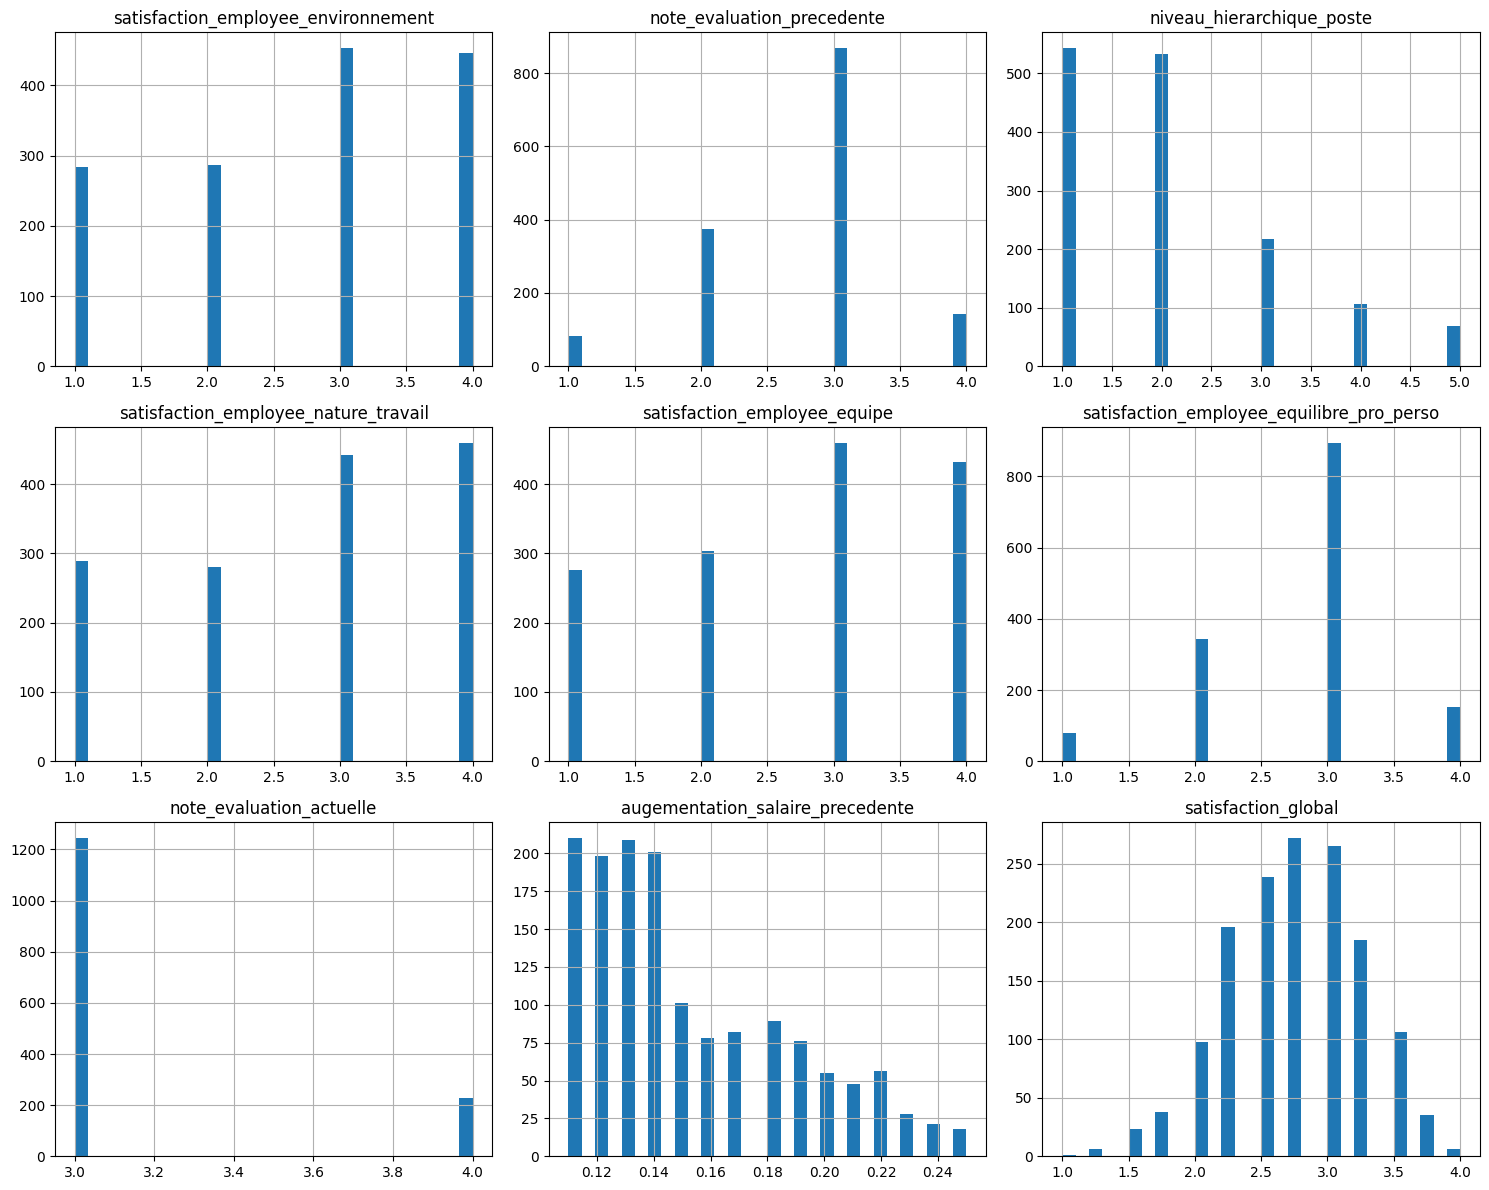

In [49]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

### C. Variable binaires (heure supplémentaires)

In [50]:
df_eval["heure_supplementaires"].value_counts(normalize=True)

heure_supplementaires
0    0.717007
1    0.282993
Name: proportion, dtype: float64

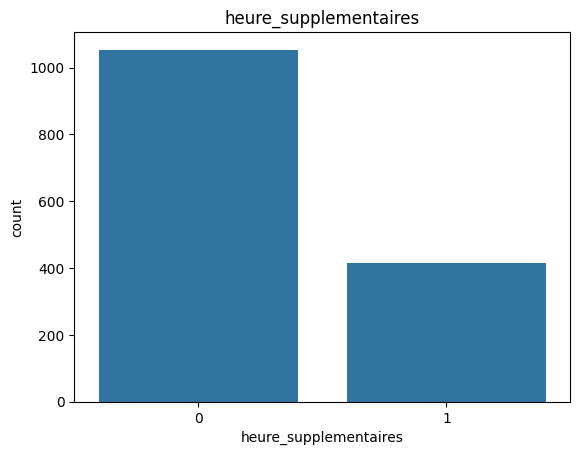

In [51]:
sns.countplot(x=df_eval["heure_supplementaires"]) 
plt.title("heure_supplementaires") 
plt.show()

In [52]:
df_eval["eval_number"] = df_eval["eval_number"].str.replace("E_","").astype(int)

## Analyses bivariées

In [53]:
df_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   satisfaction_employee_environnement        1470 non-null   int64  
 1   note_evaluation_precedente                 1470 non-null   int64  
 2   niveau_hierarchique_poste                  1470 non-null   int64  
 3   satisfaction_employee_nature_travail       1470 non-null   int64  
 4   satisfaction_employee_equipe               1470 non-null   int64  
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64  
 6   eval_number                                1470 non-null   int64  
 7   note_evaluation_actuelle                   1470 non-null   int64  
 8   heure_supplementaires                      1470 non-null   int64  
 9   augementation_salaire_precedente           1470 non-null   float64
 10  satisfaction_global     

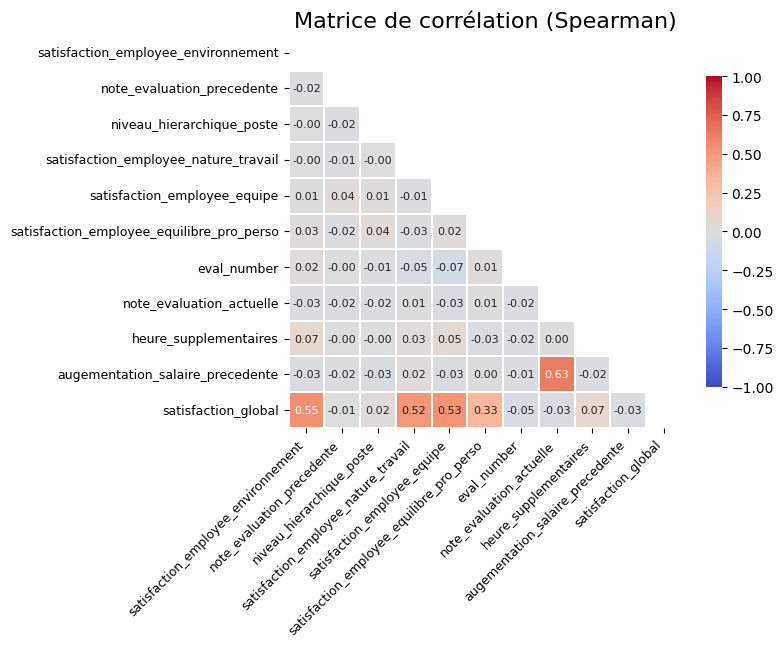

In [54]:
corr_matrix = df_eval.select_dtypes(include='number').corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [55]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr_matrix.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.5]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,note_evaluation_actuelle,augementation_salaire_precedente,0.628519
1,satisfaction_employee_environnement,satisfaction_global,0.546287
2,satisfaction_employee_equipe,satisfaction_global,0.525606
3,satisfaction_employee_nature_travail,satisfaction_global,0.522293


In [56]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = df_eval[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

,feature,VIF
0,note_evaluation_actuelle,78.778092
1,satisfaction_global,220.575430
2,satisfaction_employee_equipe,24.295293
3,satisfaction_employee_nature_travail,23.541014
4,augementation_salaire_precedente,39.832365
5,satisfaction_employee_environnement,24.512506


# A.3 Table sondage 

In [57]:
poll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [58]:
poll.head(5)

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


## Premier nettoyage des données 🧹

### Valeurs nulles 👌(❎ pas de valeurs nulles)

In [59]:
poll.isna().mean()

a_quitte_l_entreprise                  0.0
nombre_participation_pee               0.0
nb_formations_suivies                  0.0
nombre_employee_sous_responsabilite    0.0
code_sondage                           0.0
distance_domicile_travail              0.0
niveau_education                       0.0
domaine_etude                          0.0
ayant_enfants                          0.0
frequence_deplacement                  0.0
annees_depuis_la_derniere_promotion    0.0
annes_sous_responsable_actuel          0.0
dtype: float64

### Suppression des doublons 👥 (❎ Pas de doublons)

In [60]:
poll.duplicated().sum()

0

## Analyses univariées

### A.Valeurs ordinales (domaine_etude, frequence_déplacement)

In [61]:
poll.domaine_etude.value_counts()

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

In [62]:
poll.columns

Index(['a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'code_sondage', 'distance_domicile_travail', 'niveau_education',
       'domaine_etude', 'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

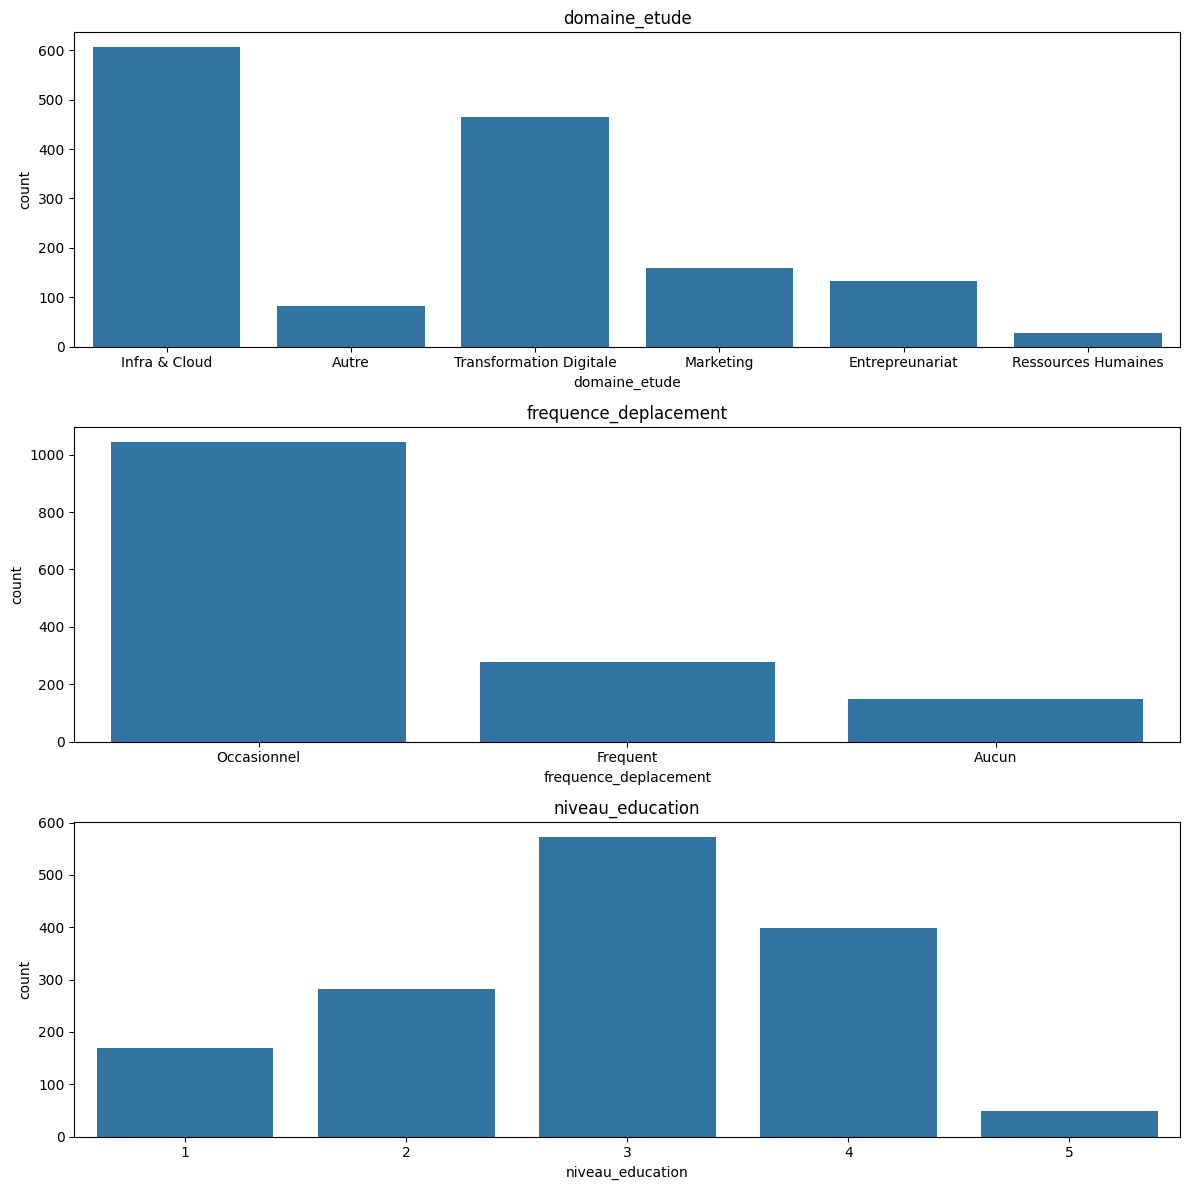

In [63]:
cols = poll[["domaine_etude","frequence_deplacement","niveau_education"]].columns

n_cols = 1  # 👉 2 graphes par ligne
n_plots = len(cols)
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=poll[col], ax=axes[i])
    axes[i].set_title(col)

# supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### B. Valeurs quantitatives

In [64]:
data = poll[['nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'distance_domicile_travail', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']].copy()

#### Swed

In [65]:
data.skew().sort_values(ascending=False)

annees_depuis_la_derniere_promotion    1.984290
nombre_participation_pee               0.968980
distance_domicile_travail              0.958118
annes_sous_responsable_actuel          0.833451
nb_formations_suivies                  0.553124
nombre_employee_sous_responsabilite    0.000000
dtype: float64

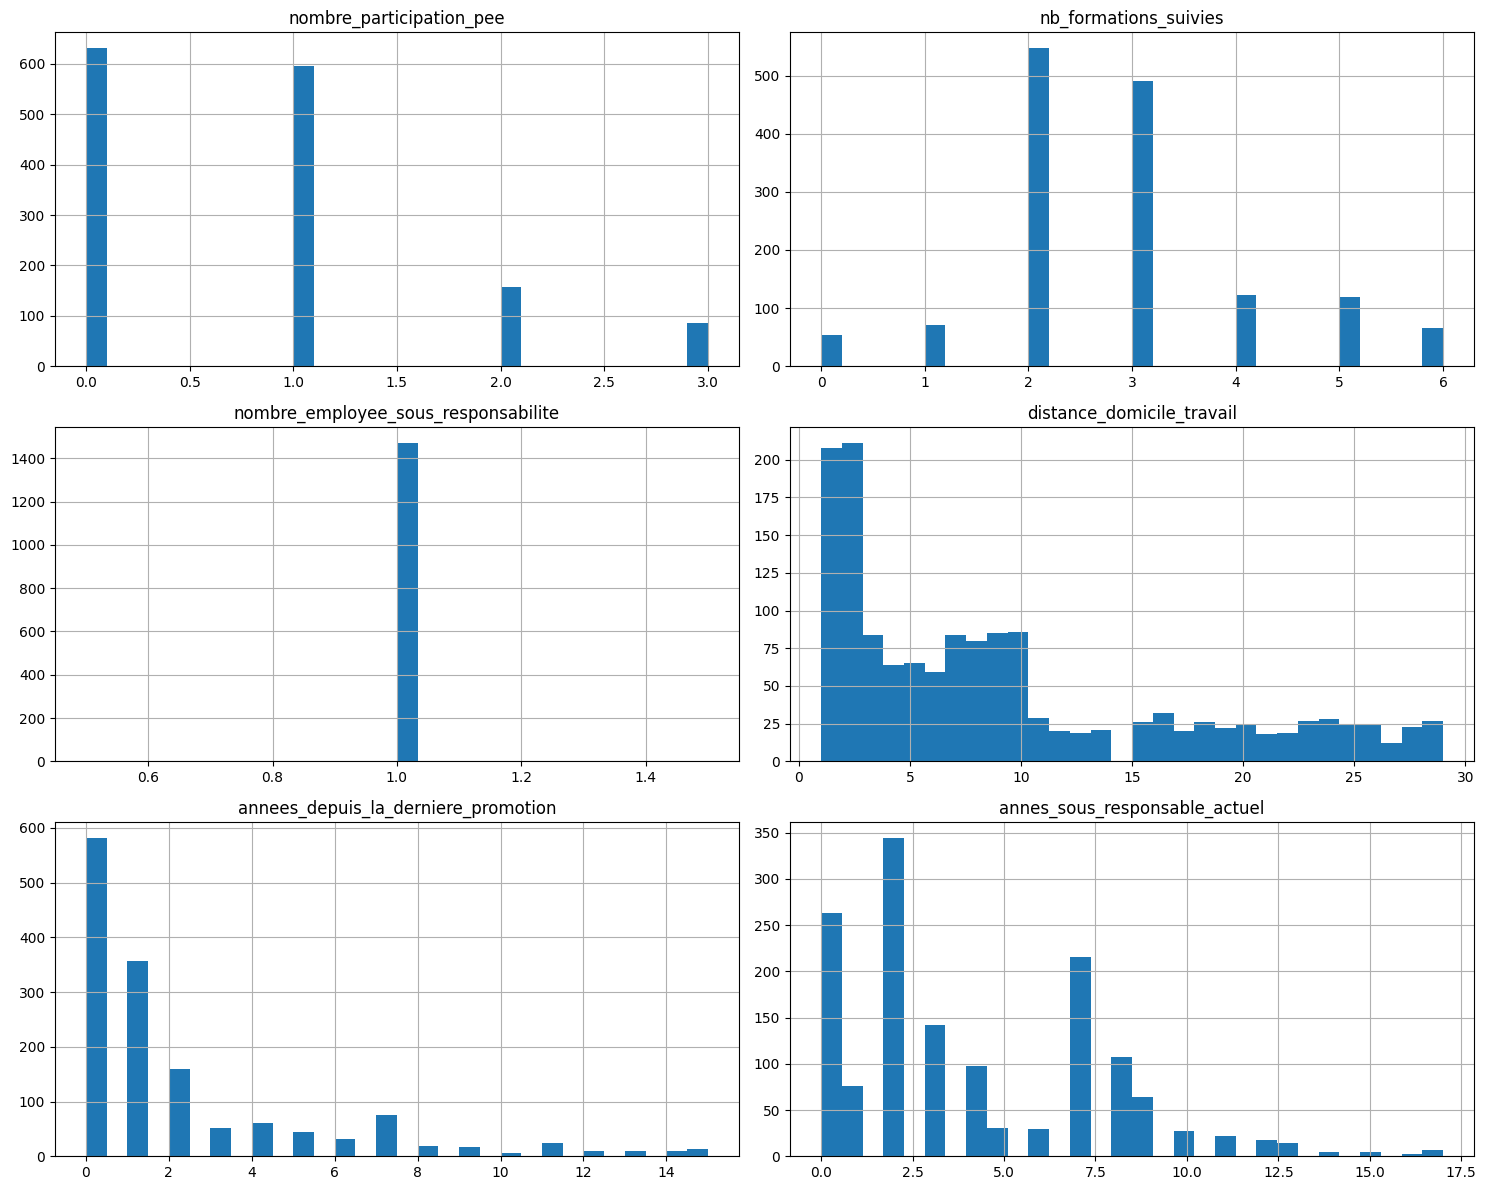

In [66]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

In [67]:
poll.nombre_employee_sous_responsabilite.describe()

count    1470.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: nombre_employee_sous_responsabilite, dtype: float64

#### Outliers

In [68]:
outliers, ratio = of.detect_outliers_iqr(data)
ratio.sort_values(ascending=False)

nb_formations_suivies                  16.190476
annees_depuis_la_derniere_promotion     7.278912
nombre_participation_pee                5.782313
annes_sous_responsable_actuel           0.952381
nombre_employee_sous_responsabilite     0.000000
distance_domicile_travail               0.000000
dtype: float64

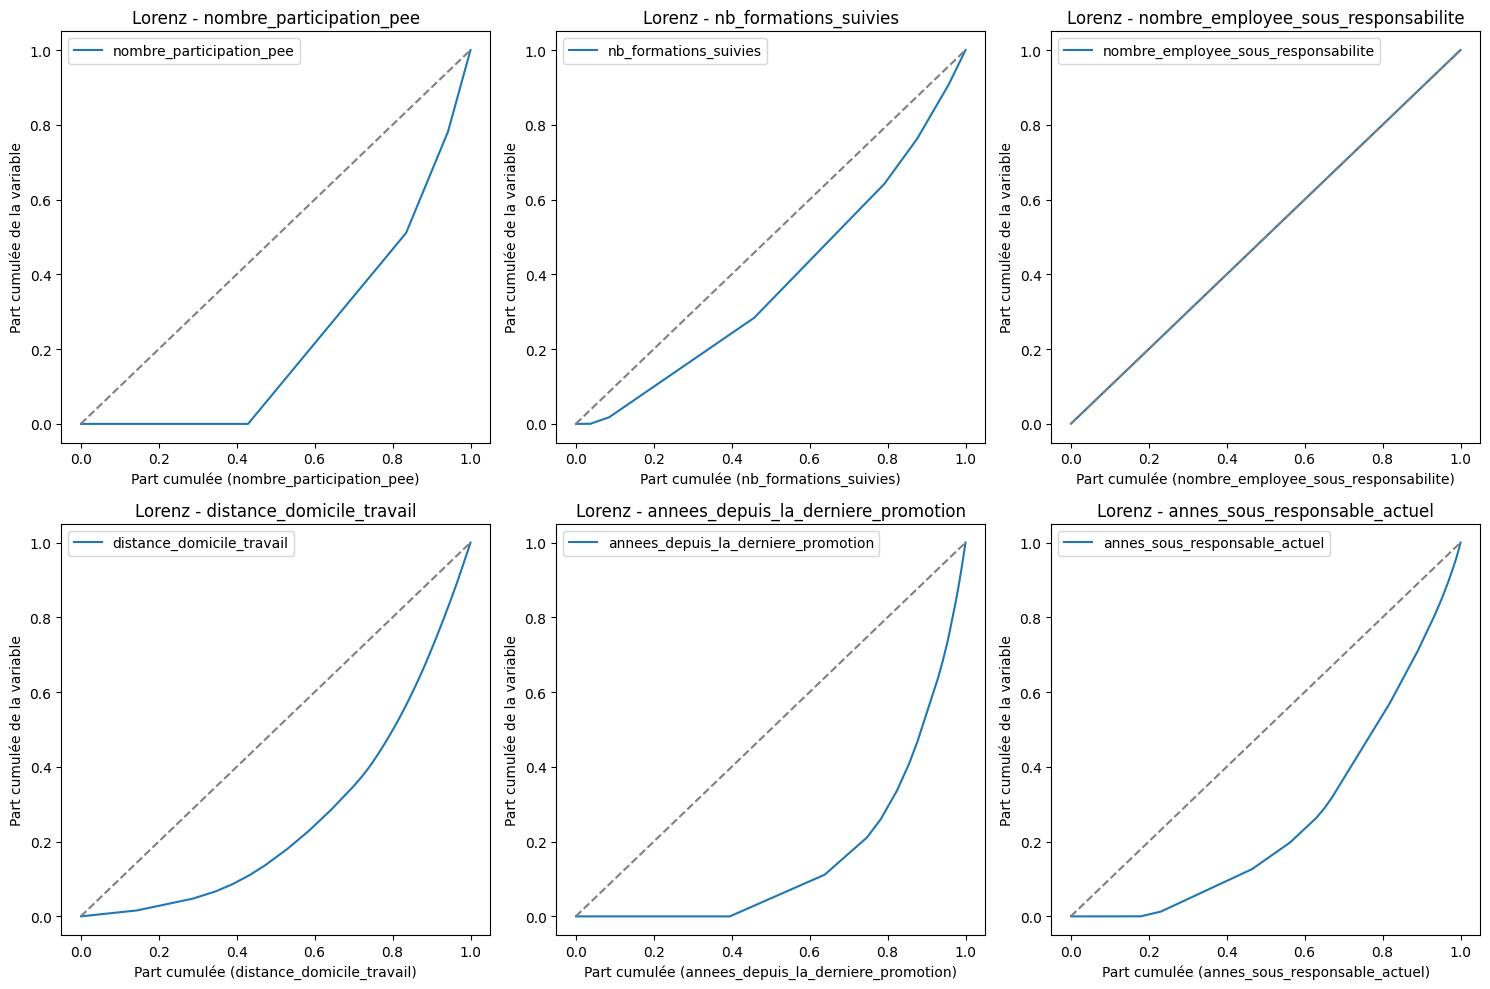

In [69]:
n_cols = 3
n_plots = len(data.columns)

n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, (col, serie) in enumerate(data.items()):
    of.plot_lorenz(
        serie,
        ax=axes[i],
        label=col,
        title=f"Lorenz - {col}"
    )

# Supprimer les axes vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

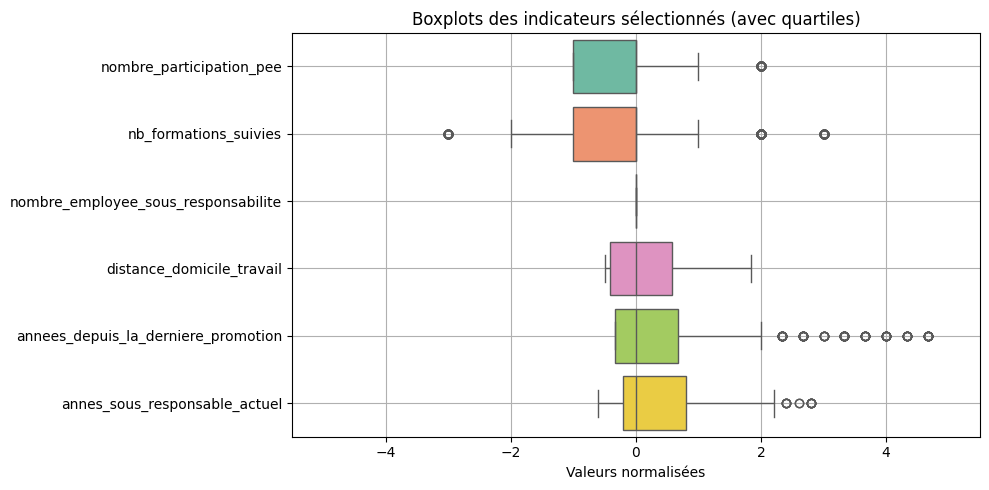

In [70]:
data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data),
    columns=data.columns
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("")
plt.xlabel("Valeurs normalisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()

### C. Valeurs binaires

In [71]:
poll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   object
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

In [72]:
poll.a_quitte_l_entreprise.value_counts(normalize=True)

a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64

In [73]:
poll["a_quitte_l_entreprise"] = (
    poll["a_quitte_l_entreprise"]
    .map({"Oui": 1, "Non": 0})
)

In [74]:
poll.ayant_enfants.value_counts() # valeur aberrante, à supprimer

ayant_enfants
Y    1470
Name: count, dtype: int64

## Analyse bivariée 🪢

In [75]:
poll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   a_quitte_l_entreprise                1470 non-null   int64 
 1   nombre_participation_pee             1470 non-null   int64 
 2   nb_formations_suivies                1470 non-null   int64 
 3   nombre_employee_sous_responsabilite  1470 non-null   int64 
 4   code_sondage                         1470 non-null   int64 
 5   distance_domicile_travail            1470 non-null   int64 
 6   niveau_education                     1470 non-null   int64 
 7   domaine_etude                        1470 non-null   object
 8   ayant_enfants                        1470 non-null   object
 9   frequence_deplacement                1470 non-null   object
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64 
 11  annes_sous_responsable_actuel        1470 n

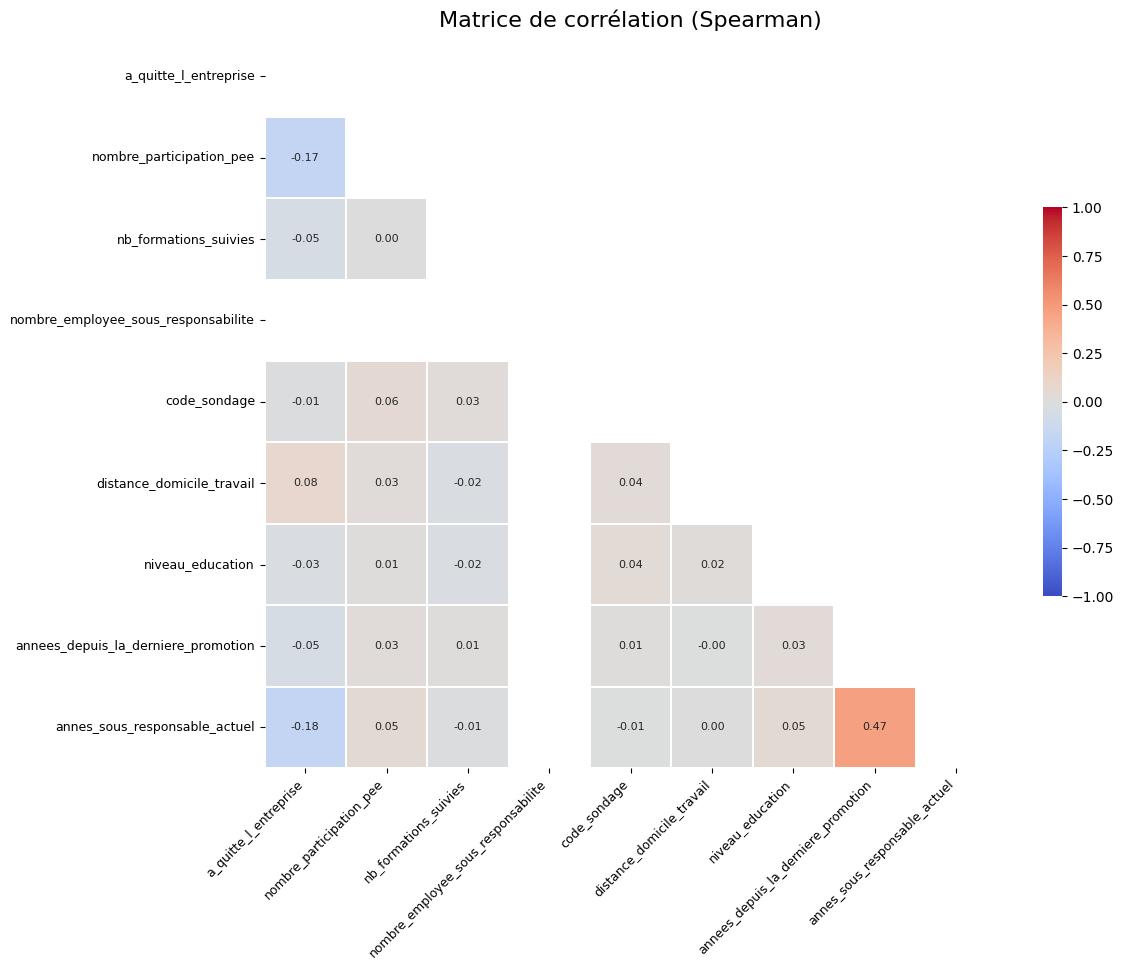

In [76]:
corr_matrix = poll.select_dtypes(include='number').corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [77]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr_matrix.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.4]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,0.466713


# B. Feature engineering

In [78]:
df = (
    info
    .merge(df_eval,left_on="id_employee",right_on="eval_number",how='inner')
    .merge(poll,left_on="id_employee",right_on="code_sondage",how='inner')
)
df.head(5)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

## Tranches d'âge

In [80]:
df.age.describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: age, dtype: float64

In [81]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[17,30,40,50,60],
    labels=["18-30","30-40","40-50","50-60"]
)

In [82]:
df[["age","age_bin"]]

,age,age_bin
0,41,40-50
1,49,40-50
2,37,30-40
3,33,30-40
4,27,18-30
...,...,...
1465,36,30-40
1466,39,30-40
1467,27,18-30
1468,49,40-50


## Tranches de revenu


In [83]:
df.revenu_mensuel.describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: revenu_mensuel, dtype: float64

In [84]:
df["revenu_bin"] = pd.qcut(df["revenu_mensuel"], q=4)

In [85]:
ct = pd.crosstab(df["age_bin"], df["revenu_bin"],normalize='index').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
age_bin,,,,
18-30,0.4663,0.3187,0.1554,0.0596
30-40,0.2084,0.2698,0.3247,0.1971
40-50,0.1335,0.1894,0.2453,0.4317
50-60,0.1189,0.1049,0.1888,0.5874


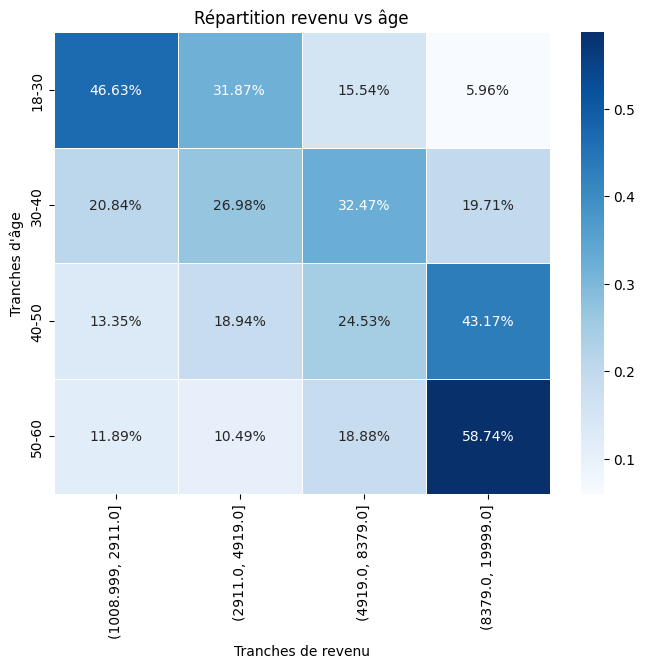

In [86]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs âge")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranches d'âge")

plt.show()

In [87]:
ct = pd.crosstab(df["genre"], df["revenu_bin"],normalize='all')
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
genre,,,,
F,0.091837,0.101361,0.102721,0.104082
M,0.159184,0.147619,0.146939,0.146259


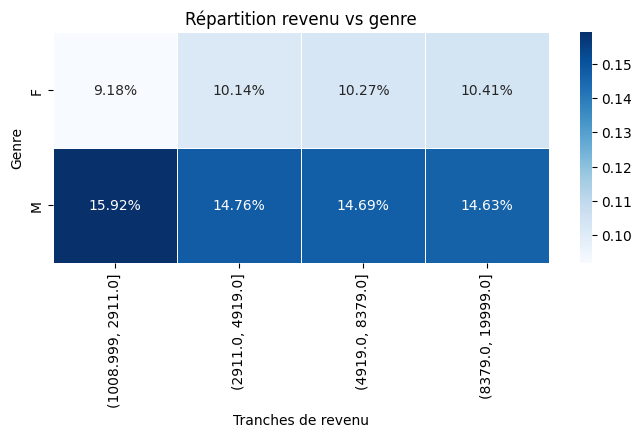

In [88]:
plt.figure(figsize=(8, 3))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs genre")
plt.xlabel("Tranches de revenu")
plt.ylabel("Genre")

plt.show()

## département

In [89]:
ct = pd.crosstab(df["departement"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
departement,,,,
Commercial,0.0435,0.0612,0.1129,0.0857
Consulting,0.1918,0.1796,0.1286,0.1537
Ressources Humaines,0.0156,0.0082,0.0082,0.0109


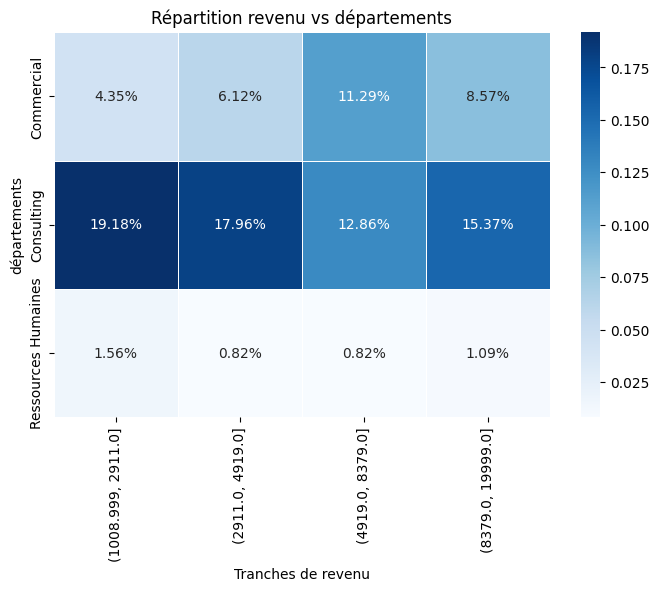

In [90]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs départements")
plt.xlabel("Tranches de revenu")
plt.ylabel("départements")

plt.show()

## Poste

In [91]:
ct = pd.crosstab(df["poste"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
poste,,,,
Assistant de Direction,0.1034,0.0741,0.0204,0.0007
Cadre Commercial,0.0000,0.0497,0.1116,0.0605
Consultant,0.0884,0.0707,0.0170,0.0000
Directeur Technique,0.0000,0.0000,0.0000,0.0544
Manager,0.0000,0.0136,0.0449,0.0306
Représentant Commercial,0.0435,0.0116,0.0014,0.0000
Ressources Humaines,0.0156,0.0082,0.0082,0.0034
Senior Manager,0.0000,0.0000,0.0000,0.0694
Tech Lead,0.0000,0.0211,0.0463,0.0313


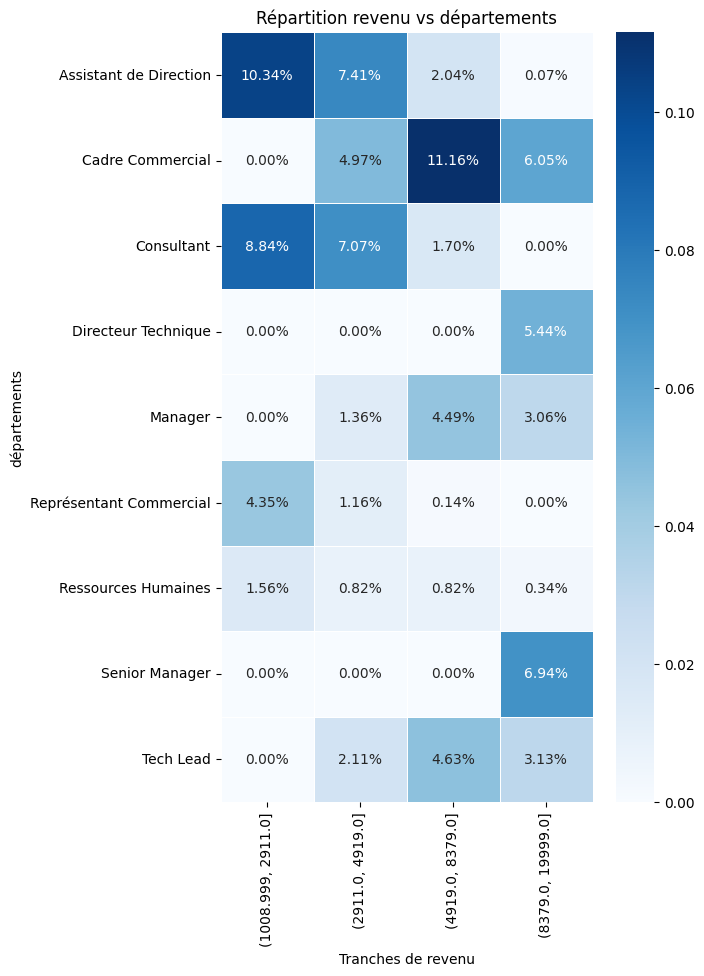

In [92]:
plt.figure(figsize=(6, 10))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs départements")
plt.xlabel("Tranches de revenu")
plt.ylabel("départements")

plt.show()

## Niveau hiérarchique

In [93]:
ct = pd.crosstab(df["niveau_hierarchique_poste"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
niveau_hierarchique_poste,,,,
1,0.2422,0.1245,0.0027,0.0000
2,0.0088,0.1245,0.2102,0.0197
3,0.0000,0.0000,0.0367,0.1116
4,0.0000,0.0000,0.0000,0.0721
5,0.0000,0.0000,0.0000,0.0469


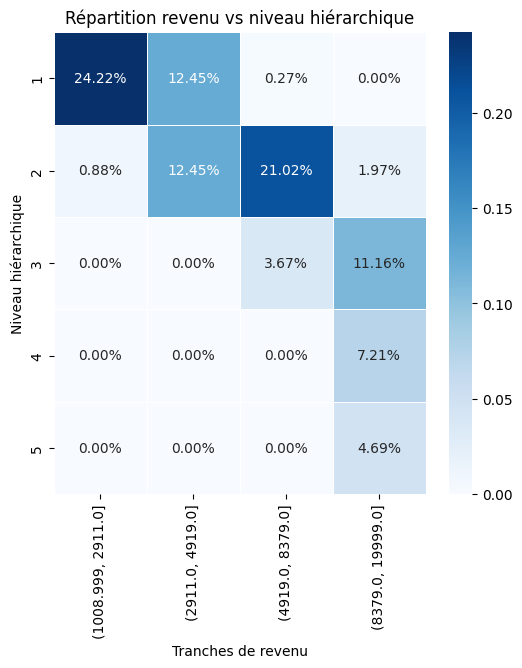

In [94]:
plt.figure(figsize=(6, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs niveau hiérarchique")
plt.xlabel("Tranches de revenu")
plt.ylabel("Niveau hiérarchique")

plt.show()

## Expériences

In [95]:
ct = pd.crosstab(df["nombre_experiences_precedentes"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
nombre_experiences_precedentes,,,,
0,0.0340,0.0463,0.0265,0.0272
1,0.1299,0.0905,0.0782,0.0558
2,0.0136,0.0211,0.0293,0.0354
3,0.0170,0.0231,0.0259,0.0422
4,0.0218,0.0170,0.0286,0.0272
5,0.0068,0.0129,0.0122,0.0109
6,0.0116,0.0082,0.0136,0.0143
7,0.0054,0.0129,0.0143,0.0177
8,0.0061,0.0082,0.0116,0.0075


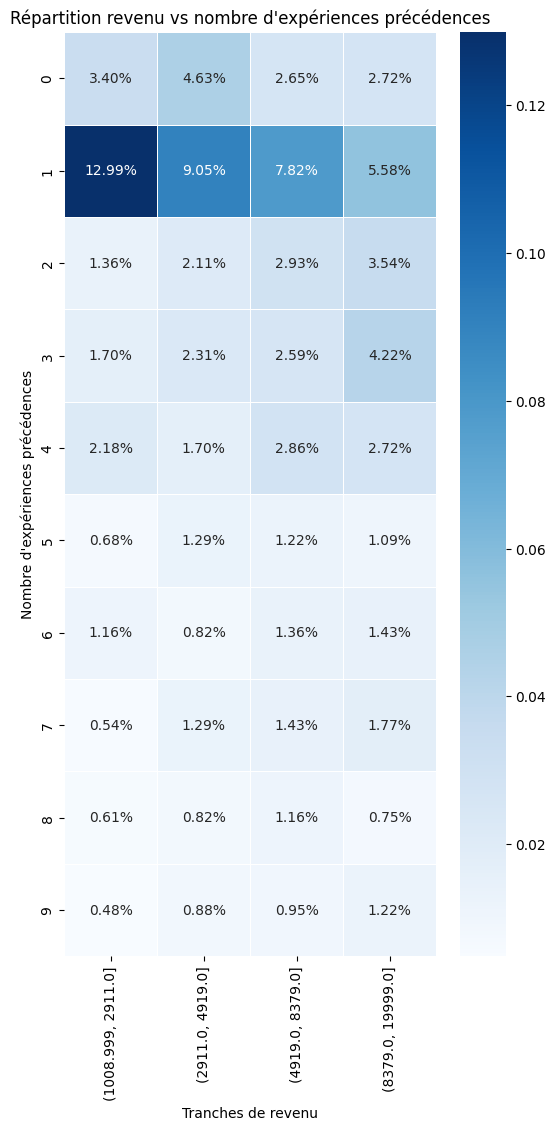

In [96]:
plt.figure(figsize=(6, 12))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs nombre d'expériences précédences")
plt.xlabel("Tranches de revenu")
plt.ylabel("Nombre d'expériences précédences")

plt.show()

## Tranche d'années expérience total

In [97]:
df["xp_total_bin"] = pd.qcut(df["annee_experience_totale"], q=4)

In [98]:
ct = pd.crosstab(df["xp_total_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
xp_total_bin,,,,
"(-0.001, 6.0]",0.1626,0.1068,0.0272,0.0034
"(6.0, 10.0]",0.0619,0.0905,0.1286,0.0469
"(10.0, 15.0]",0.0156,0.0245,0.0578,0.0320
"(15.0, 40.0]",0.0109,0.0272,0.0361,0.1680


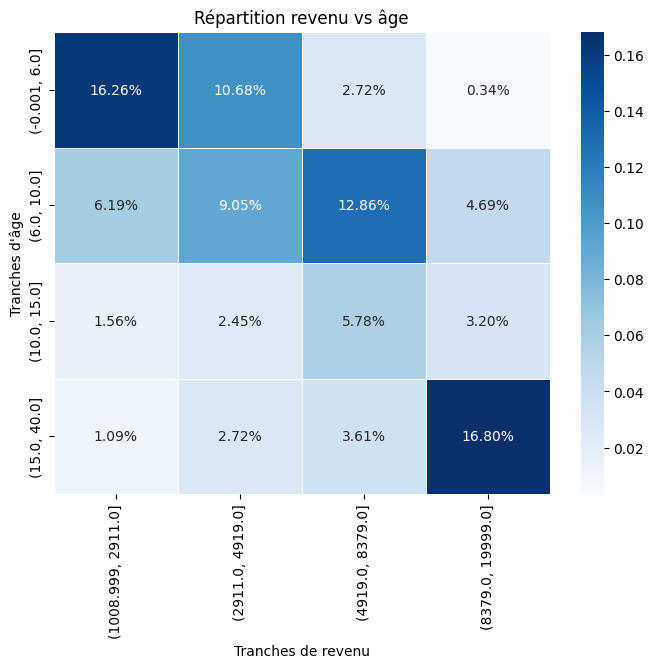

In [99]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs âge")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranches d'âge")

plt.show()

## Tranches d'années dans l'entreprise

In [100]:
df["xp_entr_bin"] = pd.qcut(df["annees_dans_l_entreprise"], q=4)

In [101]:
ct = pd.crosstab(df["xp_entr_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
xp_entr_bin,,,,
"(-0.001, 3.0]",0.1449,0.0837,0.0483,0.0429
"(3.0, 5.0]",0.0565,0.0714,0.0483,0.0320
"(5.0, 9.0]",0.0347,0.0503,0.0850,0.0531
"(9.0, 40.0]",0.0150,0.0435,0.0680,0.1224


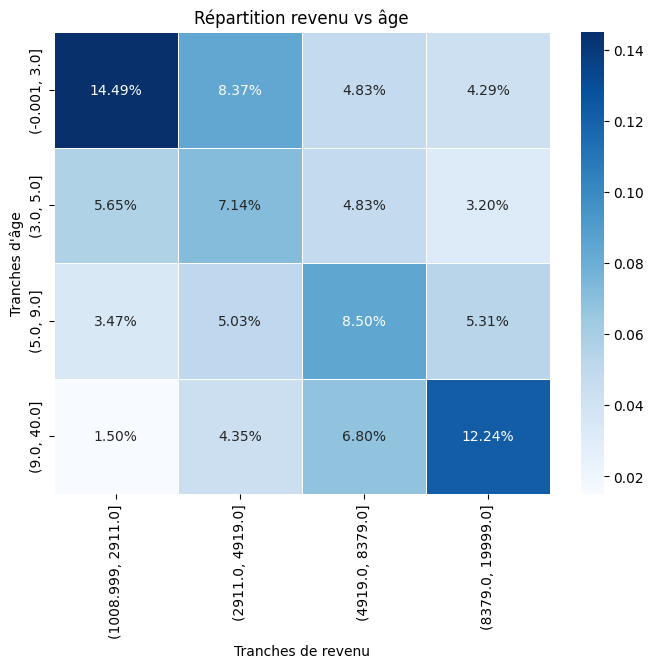

In [102]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs âge")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranches d'âge")

plt.show()

## Tranches d'années dans le poste actuel

In [103]:
df["xp_entr_bin"] = pd.qcut(df["annees_dans_le_poste_actuel"], q=4)

In [104]:
ct = pd.crosstab(df["xp_entr_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
xp_entr_bin,,,,
"(-0.001, 2.0]",0.1816,0.1224,0.0850,0.0687
"(2.0, 3.0]",0.0238,0.0299,0.0245,0.0136
"(3.0, 7.0]",0.0361,0.0633,0.0925,0.0796
"(7.0, 18.0]",0.0095,0.0333,0.0476,0.0884


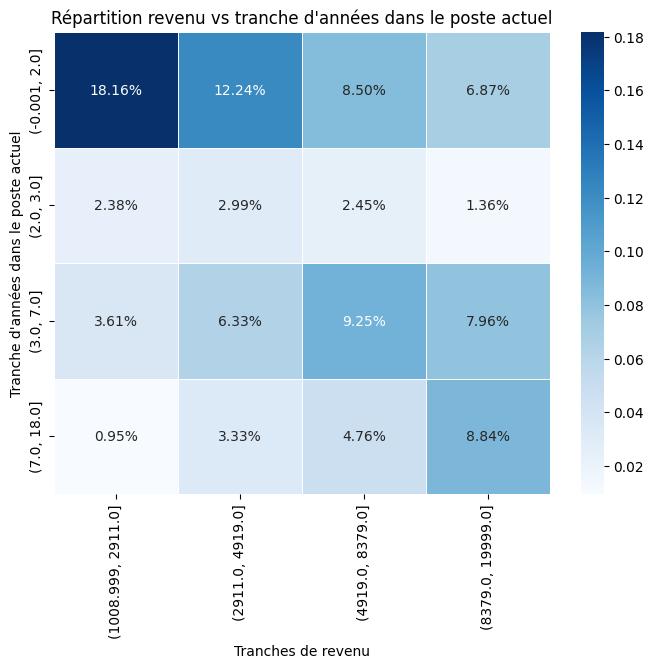

In [105]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs tranche d'années dans le poste actuel")
plt.xlabel("Tranches de revenu")
plt.ylabel("Tranche d'années dans le poste actuel")

plt.show()

## Satisfactions

In [106]:
df["satisfaction_bin"] = pd.qcut(df["satisfaction_global"], q=4)

In [107]:
ct = pd.crosstab(df["satisfaction_bin"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
satisfaction_bin,,,,
"(0.999, 2.5]",0.0973,0.1088,0.1014,0.1014
"(2.5, 2.75]",0.0524,0.0497,0.0415,0.0415
"(2.75, 3.0]",0.0422,0.0381,0.0497,0.0503
"(3.0, 4.0]",0.0592,0.0524,0.0571,0.0571


In [108]:
df_eval.columns

Index(['satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'eval_number',
       'note_evaluation_actuelle', 'heure_supplementaires',
       'augementation_salaire_precedente', 'satisfaction_global'],
      dtype='object')

## Evaluation

In [109]:
# Evaluation
df["delta_evaluation"] = (
    df["note_evaluation_actuelle"] - df["note_evaluation_precedente"]
)

In [110]:
df["delta_evaluation"].value_counts()

delta_evaluation
 0    757
 1    448
 2    124
-1    124
 3     17
Name: count, dtype: int64

In [111]:
ct = pd.crosstab(df["delta_evaluation"], df["revenu_bin"],normalize='all').round(4)
ct

revenu_bin,"(1008.999, 2911.0]","(2911.0, 4919.0]","(4919.0, 8379.0]","(8379.0, 19999.0]"
delta_evaluation,,,,
-1,0.0204,0.0211,0.0252,0.0177
0,0.1238,0.1401,0.1252,0.1259
1,0.0810,0.0673,0.0762,0.0803
2,0.0238,0.0184,0.0184,0.0238
3,0.0020,0.0020,0.0048,0.0027


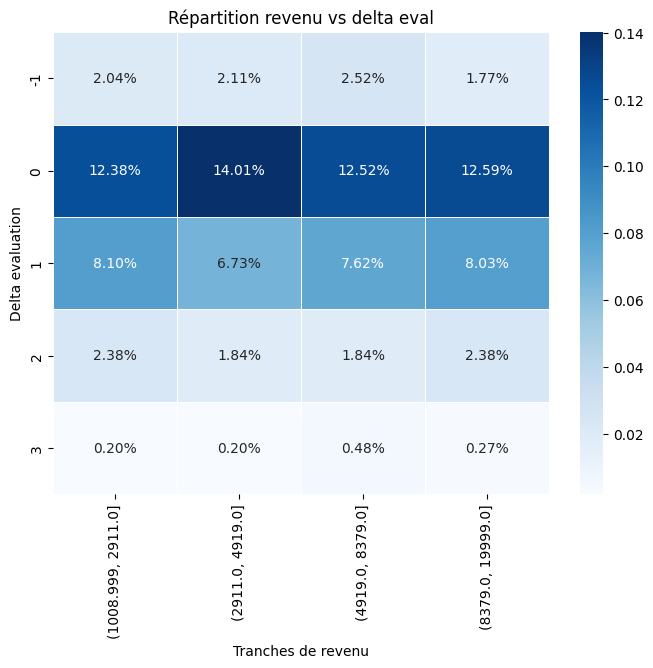

In [112]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Répartition revenu vs delta eval")
plt.xlabel("Tranches de revenu")
plt.ylabel("Delta evaluation")

plt.show()

In [113]:
ct = pd.crosstab(df["delta_evaluation"], df["satisfaction_bin"],normalize='all').round(4)
ct

satisfaction_bin,"(0.999, 2.5]","(2.5, 2.75]","(2.75, 3.0]","(3.0, 4.0]"
delta_evaluation,,,,
-1,0.0361,0.0170,0.0116,0.0197
0,0.2095,0.0884,0.1007,0.1163
1,0.1204,0.0633,0.0524,0.0687
2,0.0367,0.0143,0.0156,0.0177
3,0.0061,0.0020,0.0000,0.0034


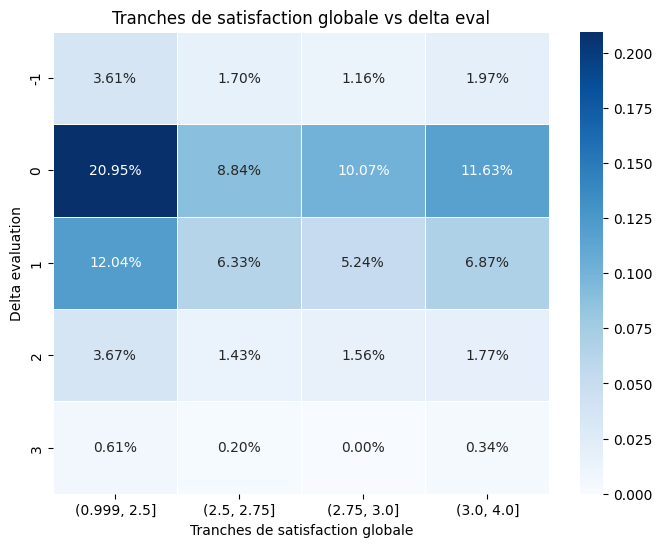

In [114]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Tranches de satisfaction globale vs delta eval")
plt.xlabel("Tranches de satisfaction globale")
plt.ylabel("Delta evaluation")

plt.show()

In [115]:
df["evaluation_declined"] = (df["delta_evaluation"] < 0).astype(int)

## Augmentations

In [116]:
df["bin_raise"] = pd.qcut(df["augementation_salaire_precedente"],q=4)

In [117]:
ct = pd.crosstab(df["bin_raise"], df["delta_evaluation"],normalize='all').round(4)
ct

delta_evaluation,-1,0,1,2,3
bin_raise,,,,,
"(0.109, 0.12]",0.0293,0.1680,0.0694,0.0109,0.0000
"(0.12, 0.14]",0.0184,0.1707,0.0735,0.0163,0.0000
"(0.14, 0.18]",0.0313,0.1333,0.0585,0.0150,0.0000
"(0.18, 0.25]",0.0054,0.0429,0.1034,0.0422,0.0116


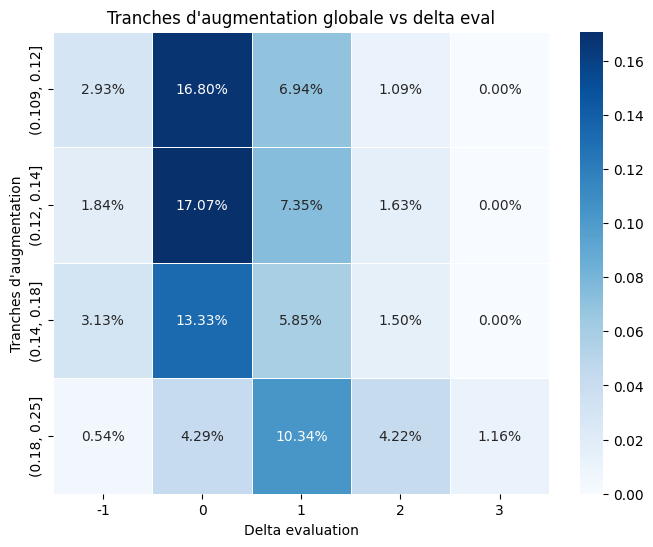

In [118]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)


plt.title("Tranches d'augmentation globale vs delta eval")
plt.ylabel("Tranches d'augmentation")
plt.xlabel("Delta evaluation")

plt.show()

In [136]:
ct = pd.crosstab(df["bin_raise"], df["note_evaluation_actuelle"],normalize='all').round(4)
ct

note_evaluation_actuelle,3,4
bin_raise,,
"(0.109, 0.12]",0.2776,0.0000
"(0.12, 0.14]",0.2789,0.0000
"(0.14, 0.18]",0.2381,0.0000
"(0.18, 0.25]",0.0517,0.1537


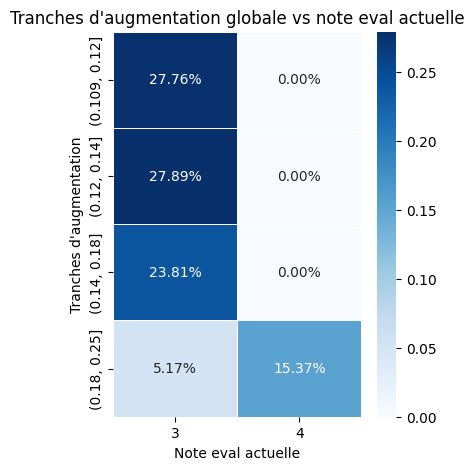

In [140]:
plt.figure(figsize=(4, 5))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)


plt.title("Tranches d'augmentation globale vs note eval actuelle")
plt.xlabel("Note eval actuelle")
plt.ylabel("Tranches d'augmentation")

plt.show()

## Distance domicile travail

In [121]:
df["distance_bin"] = pd.qcut(df["distance_domicile_travail"], q=4)

In [132]:
ct = pd.crosstab(df["distance_bin"], df["satisfaction_bin"],normalize='columns').round(4)
ct

satisfaction_bin,"(0.999, 2.5]","(2.5, 2.75]","(2.75, 3.0]","(3.0, 4.0]"
distance_bin,,,,
"(0.999, 2.0]",0.2762,0.2684,0.3132,0.2922
"(2.0, 7.0]",0.2246,0.2978,0.2340,0.2349
"(7.0, 14.0]",0.2446,0.2132,0.2415,0.2139
"(14.0, 29.0]",0.2546,0.2206,0.2113,0.2590


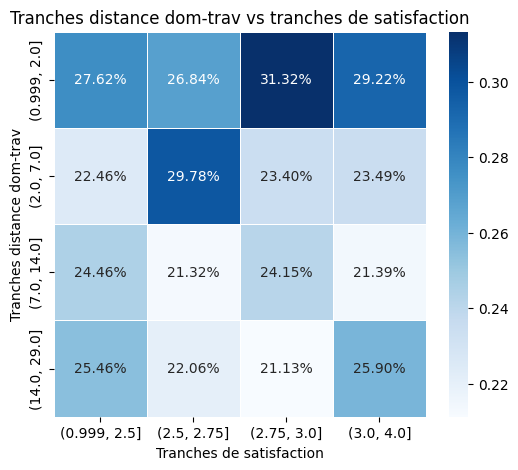

In [133]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    ct,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    linewidths=0.5
)


plt.title("Tranches distance dom-trav vs tranches de satisfaction")
plt.xlabel("Tranches de satisfaction")
plt.ylabel("Tranches distance dom-trav")

plt.show()

## Log des valeurs extrêmes

In [143]:
outliers, ratio = of.detect_outliers_iqr(df.select_dtypes(include="number"))

ratio.sort_values(ascending=False)

nb_formations_suivies                        16.190476
a_quitte_l_entreprise                        16.122449
note_evaluation_actuelle                     15.374150
evaluation_declined                           8.435374
revenu_mensuel                                7.755102
annees_depuis_la_derniere_promotion           7.278912
annees_dans_l_entreprise                      7.074830
nombre_participation_pee                      5.782313
annee_experience_totale                       4.285714
nombre_experiences_precedentes                3.537415
satisfaction_global                           2.448980
annees_dans_le_poste_actuel                   1.428571
delta_evaluation                              1.156463
annes_sous_responsable_actuel                 0.952381
niveau_education                              0.000000
distance_domicile_travail                     0.000000
code_sondage                                  0.000000
augementation_salaire_precedente              0.000000
heure_supp

In [144]:
df["log_revenu"] = np.log1p(df["revenu_mensuel"])
df["log_dist_dom_trav"] = np.log1p(df["distance_domicile_travail"])
df["log_annees_depuis_last_promo"] = np.log1p(df["annees_depuis_la_derniere_promotion"])
df["log_annees_in_entr"] = np.log1p(df["annees_dans_l_entreprise"])
df["log_annee_experience_totale"] = np.log1p(df["annee_experience_totale"])
df["log_annees_poste_actuel"] = np.log1p(df["annees_dans_le_poste_actuel"])

# Last cleaning

In [141]:
df = df.loc[:, df.nunique() > 1]

# Export 

In [146]:
df.to_csv("/home/maxime/projects/technova-attrition/data/interim/data.csv")